# Phase 1 - DATA Preprocessing

Import the data, Sorting, Scaling, Segmentation, Loader

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler


In [2]:
# =========================
# CONFIG (edit here)
# =========================

# -------- Data --------
DATA_PATH = "Sample of machine data - 1670760-1.csv"   # update if needed
DELIMITER = ";"                                   # your CSV uses ';'
TIMESTAMP_COL = "timestamp"
TARGET_COL = "Material_Cushion"                   # REAL cushion column in file
CUSHION_INPUT_COL = "Cushion_in"   # name used in FEATURES for cushion history
# -------- Segmentation --------
MAX_GAP_SECONDS = 180  # new segment if timestamp gap > this (e.g., 2 minutes)

# -------- Sequence & Forecast --------
H = 1  # predict next 5 cushions in one shot
HISTORY = 25            # past cycles given to the model (sequence length)
SEQ_LEN = HISTORY
FORECAST_STEPS = 20     # how many future cushions to predict in the forecast plot
HIST_PLOT = 20          # how many history points to show on the plot

# -------- Train/Val/Test split --------
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15      # test is the rest

# -------- Training --------
EPOCHS = 80
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 10           # early stopping patience
GRAD_CLIP = 1.0

# -------- Model --------
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.1

RANDOM_SEED = 42


In [3]:
# Reproducibility
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Small safety checks
assert HIST_PLOT <= HISTORY, "HIST_PLOT must be <= HISTORY"


Using device: cuda


In [4]:
# =========================
# Load & prepare data
# =========================
df = pd.read_csv(DATA_PATH, delimiter=DELIMITER)

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], dayfirst=True, errors="coerce")
df = df.dropna(subset=[TIMESTAMP_COL]).sort_values(TIMESTAMP_COL).reset_index(drop=True)

# Build segments to avoid learning across long machine stops
df["dt_sec"] = df[TIMESTAMP_COL].diff().dt.total_seconds()
df["segment"] = (df["dt_sec"] > MAX_GAP_SECONDS).cumsum()
df.drop(columns=["dt_sec"], inplace=True)

print("Rows:", len(df), "| Segments:", df["segment"].nunique())
df.head()


Rows: 25788 | Segments: 19


,timestamp,Cycle_Time,Maximum_Injection_Pressure,Switch_Over_Pressure,Injection_Time,Material_Cushion,Dosing_Time,Cycle_Counter,Machine,Circumferential_speed_ActValue,...,Cylinder_heating_zone_2_ActValue,Cylinder_heating_zone_3_ActValue,Cylinder_heating_zone_4_ActValue,Cylinder_heating_zone_5_ActValue,Monitoring_time_of_mould_protection_ActValue,Locking_force_ActValue,SwitchOver_volume_ActValue,resource_id,Part Number,segment
0,2026-01-01 00:00:00,15.588771,1467.599976,1466.500000,1.011936,10.36,2.333299,55667,M1007,0.519,...,285.100006,280.100006,270.100006,270.000000,1.481827,1218.800049,12.99,M1946414,1670760-1,0
1,2026-01-01 00:00:00,15.558787,1485.800049,1484.599976,1.011967,10.38,2.352199,55668,M1007,0.520,...,285.000000,280.000000,270.100006,270.000000,1.481796,1218.099976,13.00,M1946414,1670760-1,0
2,2026-01-01 00:00:00,15.570118,1490.400024,1489.199951,1.011966,10.38,2.339897,55669,M1007,0.520,...,285.000000,279.899994,270.200012,270.100006,1.481583,1219.300049,13.00,M1946414,1670760-1,0
3,2026-01-01 00:00:00,15.578292,1468.599976,1467.500000,1.011944,10.38,2.322458,55670,M1007,0.520,...,285.100006,280.000000,270.100006,270.100006,1.481844,1218.900024,12.99,M1946414,1670760-1,0
4,2026-01-01 00:01:00,15.569985,1484.199951,1483.199951,1.011924,10.38,2.351245,55671,M1007,0.520,...,285.100006,280.000000,270.100006,270.100006,1.481799,1218.900024,13.00,M1946414,1670760-1,0


In [5]:
# =========================
# Choose recipe-controllable features
# (add/remove based on what you can plan/set)
# =========================

RECIPE_FEATURES = [
    # You can uncomment/add if you have these and they are meaningful as "settable" variables:
    "Maximum_Injection_Pressure",
    "Switch_Over_Pressure",
    "Injection_Time",
    "Dosing_Time",
    #"Cycle_Time",

    "Back_pressure_ActValue",
    "SwitchOver_volume_ActValue",
    "Dosing_Volume_ActValue",
    #"Total_holding_pressure_time_ActValue",
    #"Remaining_cooling_time_ActValue",
]

# We add an extra input column for cushion history (NARX idea)
CUSHION_IN_COL = "Cushion_in"

# Create cushion input column (copy of raw target)
df[CUSHION_IN_COL] = df[TARGET_COL].astype(float)

# Final FEATURES used by the GRU (recipe + cushion history)
FEATURES = RECIPE_FEATURES + [CUSHION_IN_COL]

# Basic cleaning: keep only needed cols and drop missing rows
needed = [TIMESTAMP_COL, "segment"] + FEATURES + [TARGET_COL]
df = df[needed].copy()
df = df.dropna().reset_index(drop=True)

print("Kept rows after dropna:", len(df))
print("FEATURES:", FEATURES)


Kept rows after dropna: 25788
FEATURES: ['Maximum_Injection_Pressure', 'Switch_Over_Pressure', 'Injection_Time', 'Dosing_Time', 'Back_pressure_ActValue', 'SwitchOver_volume_ActValue', 'Dosing_Volume_ActValue', 'Cushion_in']


In [6]:
# =========================
# Split (time-ordered) and keep RAW copies
# =========================
n = len(df)
train_end = int(TRAIN_RATIO * n)
val_end = int((TRAIN_RATIO + VAL_RATIO) * n)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

# RAW copies for plotting and for fitting scalers safely
df_train_raw = df_train.copy()
df_val_raw   = df_val.copy()
df_test_raw  = df_test.copy()

print("Train/Val/Test:", len(df_train), len(df_val), len(df_test))


Train/Val/Test: 18051 3868 3869


In [7]:
# =========================
# Delta target creation (per split) + keep alignment
# - Delta_Cushion(t) = Cushion(t) - Cushion(t-1) within each segment
# - Drops the first row of each segment (because delta undefined)
# - Applies the same row filtering to BOTH raw and scaled dfs
# =========================

def add_delta_and_filter(df_scaled, df_raw, target_col, seg_col="segment"):
    df_scaled = df_scaled.copy()
    df_raw = df_raw.copy()

    # Compute previous cushion within each segment (RAW is the truth)
    prev = df_raw.groupby(seg_col)[target_col].shift(1)
    df_raw["Cushion_prev"] = prev
    df_raw["Delta_Cushion"] = df_raw[target_col] - df_raw["Cushion_prev"]

    # Valid rows = all except first row of each segment
    valid_mask = prev.notna().values

    # Apply same mask to BOTH dataframes to keep row-by-row alignment
    df_raw = df_raw.loc[valid_mask].reset_index(drop=True)
    df_scaled = df_scaled.loc[valid_mask].reset_index(drop=True)

    return df_scaled, df_raw

# Apply per split
df_train, df_train_raw = add_delta_and_filter(df_train, df_train_raw, TARGET_COL, "segment")
df_val,   df_val_raw   = add_delta_and_filter(df_val,   df_val_raw,   TARGET_COL, "segment")
df_test,  df_test_raw  = add_delta_and_filter(df_test,  df_test_raw,  TARGET_COL, "segment")

print("After delta filtering:")
print("Train/Val/Test:", len(df_train), len(df_val), len(df_test))
print("Delta stats (train): mean=", float(df_train_raw["Delta_Cushion"].mean()),
      "std=", float(df_train_raw["Delta_Cushion"].std(ddof=1)))


After delta filtering:
Train/Val/Test: 18033 3867 3867
Delta stats (train): mean= -1.6636271834966951e-06 std= 0.13352628632324895


In [8]:
# =========================
# Scaling (ROBUST)
# - Inputs (FEATURES) scaled with x_scaler
# - Target is now Delta_Cushion scaled with delta_scaler
# =========================

from sklearn.preprocessing import RobustScaler

# Fit scalers ONLY on TRAIN raw
x_scaler = RobustScaler(quantile_range=(5, 95))
delta_scaler = RobustScaler(quantile_range=(5, 95))

x_scaler.fit(df_train_raw[FEATURES])
delta_scaler.fit(df_train_raw[["Delta_Cushion"]])

# ---- Scale inputs
df_train[FEATURES] = x_scaler.transform(df_train_raw[FEATURES])
df_val[FEATURES]   = x_scaler.transform(df_val_raw[FEATURES])
df_test[FEATURES]  = x_scaler.transform(df_test_raw[FEATURES])

# ---- Scale delta target
TARGET_SCALED_COL = "Delta_Cushion_scaled"
df_train[TARGET_SCALED_COL] = delta_scaler.transform(df_train_raw[["Delta_Cushion"]])
df_val[TARGET_SCALED_COL]   = delta_scaler.transform(df_val_raw[["Delta_Cushion"]])
df_test[TARGET_SCALED_COL]  = delta_scaler.transform(df_test_raw[["Delta_Cushion"]])

print("delta_scaler center (median):", float(delta_scaler.center_[0]))
print("delta_scaler scale (IQR):    ", float(delta_scaler.scale_[0]))


delta_scaler center (median): 0.0
delta_scaler scale (IQR):     0.060001360000001114


In [9]:
# =========================
# Build sequences (multi-step targets)
# X: rows [t-SEQ_LEN ... t-1]
# y: [cushion(t), cushion(t+1), ... cushion(t+H-1)]  (scaled target)
# plus metadata: segment id + position t inside segment
# =========================

def build_sequences_multistep(df_scaled, features, target_scaled_col, seq_len, H):
    X, Y, seg_ids, pos_t = [], [], [], []

    for seg_id, seg in df_scaled.groupby("segment"):
        seg = seg.reset_index(drop=True)

        if len(seg) <= seq_len + H - 1:
            continue

        # target starts at time t = i+seq_len
        for i in range(len(seg) - seq_len - H + 1):
            t = i + seq_len

            x_seq = seg.loc[i:t-1, features].values.astype(np.float32)
            y_vec = seg.loc[t:t+H-1, target_scaled_col].values.astype(np.float32)  # length H

            X.append(x_seq)
            Y.append(y_vec)
            seg_ids.append(int(seg_id))
            pos_t.append(int(t))

    return (
        np.array(X, dtype=np.float32),
        np.array(Y, dtype=np.float32),   # (N, H)
        np.array(seg_ids, dtype=np.int64),
        np.array(pos_t, dtype=np.int64),
    )

X_train, Y_train, seg_train, pos_train = build_sequences_multistep(df_train, FEATURES, TARGET_SCALED_COL, SEQ_LEN, H)
X_val,   Y_val,   seg_val,   pos_val   = build_sequences_multistep(df_val,   FEATURES, TARGET_SCALED_COL, SEQ_LEN, H)
X_test,  Y_test,  seg_test,  pos_test  = build_sequences_multistep(df_test,  FEATURES, TARGET_SCALED_COL, SEQ_LEN, H)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_val  :", X_val.shape,   "Y_val  :", Y_val.shape)
print("X_test :", X_test.shape,  "Y_test :", Y_test.shape)


X_train: (17737, 25, 8) Y_train: (17737, 1)
X_val  : (3842, 25, 8) Y_val  : (3842, 1)
X_test : (3817, 25, 8) Y_test : (3817, 1)


In [10]:
# =========================
# PyTorch Dataset / Loaders (MULTI-STEP y = (B, H))
# =========================

from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, SEQ_LEN, n_features)
        self.Y = torch.tensor(Y, dtype=torch.float32)  # (N, H)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

train_loader = DataLoader(
    TimeSeriesDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    TimeSeriesDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

# Phase 2 - Model Selection Experiment

Train and compare three candidates with the same inputs and split:
1. TCN
2. GRU
3. LSTM


In [11]:
# ============================================================
# EXP CELL 1 - Shared utilities for 3-model experiment
# ============================================================

import copy
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Required notebook objects from previous cells
req = [
    "X_train", "Y_train", "X_val", "Y_val", "X_test", "Y_test",
    "FEATURES", "RECIPE_FEATURES", "SEQ_LEN", "TARGET_COL",
    "df_test", "df_test_raw", "df_train_raw", "delta_scaler", "x_scaler", "device"
]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for experiment: {missing}")

EXP_RANDOM_SEED = 123
np.random.seed(EXP_RANDOM_SEED)
torch.manual_seed(EXP_RANDOM_SEED)

# --- helpers
class ArrayDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


def make_loaders(Xtr, Ytr, Xv, Yv, batch_size=128):
    tr = DataLoader(ArrayDataset(Xtr, Ytr), batch_size=batch_size, shuffle=True, drop_last=False)
    va = DataLoader(ArrayDataset(Xv, Yv), batch_size=batch_size, shuffle=False, drop_last=False)
    return tr, va


def delta_scaled_to_real_vec(arr):
    arr = np.asarray(arr, dtype=np.float32).reshape(-1, 1)
    return delta_scaler.inverse_transform(arr).ravel()


def cushion_scaled_to_real(scaled_vals, feature_name="Cushion_in"):
    idx = FEATURES.index(feature_name)
    center = float(x_scaler.center_[idx])
    scale = float(x_scaler.scale_[idx])
    return np.asarray(scaled_vals, dtype=np.float32) * scale + center


def cushion_real_to_scaled(real_vals, feature_name="Cushion_in"):
    idx = FEATURES.index(feature_name)
    center = float(x_scaler.center_[idx])
    scale = float(x_scaler.scale_[idx])
    return (np.asarray(real_vals, dtype=np.float32) - center) / scale


def qhat_conformal(abs_errors, alpha=0.10):
    # Split conformal quantile
    e = np.sort(np.asarray(abs_errors, dtype=float))
    n = len(e)
    if n == 0:
        return np.nan
    k = int(math.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    return float(e[k - 1])


def interval_metrics(y_true, lo, hi):
    y_true = np.asarray(y_true, dtype=float)
    lo = np.asarray(lo, dtype=float)
    hi = np.asarray(hi, dtype=float)
    cov = float(np.mean((y_true >= lo) & (y_true <= hi)))
    width = float(np.mean(hi - lo))
    return cov, width


In [12]:
# ============================================================
# EXP CELL 2 - Candidate models (TCN, GRU, LSTM)
# ============================================================

class GRUOneStep(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class LSTMOneStep(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)


class TCNBlock(nn.Module):
    def __init__(self, ch_in, ch_out, kernel=3, dilation=1, dropout=0.1):
        super().__init__()
        self.kernel = kernel
        self.dilation = dilation
        self.conv1 = nn.Conv1d(ch_in, ch_out, kernel_size=kernel, dilation=dilation)
        self.conv2 = nn.Conv1d(ch_out, ch_out, kernel_size=kernel, dilation=dilation)
        self.drop = nn.Dropout(dropout)
        self.down = nn.Conv1d(ch_in, ch_out, kernel_size=1) if ch_in != ch_out else nn.Identity()

    def _causal(self, x, conv):
        pad = (self.kernel - 1) * self.dilation
        x = F.pad(x, (pad, 0))
        return conv(x)

    def forward(self, x):
        y = torch.relu(self._causal(x, self.conv1))
        y = self.drop(y)
        y = torch.relu(self._causal(y, self.conv2))
        y = self.drop(y)
        return y + self.down(x)


class TCNOneStep(nn.Module):
    def __init__(self, input_dim, channels=(32, 32), kernel=3, dropout=0.1):
        super().__init__()
        blocks = []
        ch_prev = input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(ch_prev, ch, kernel=kernel, dilation=(2 ** i), dropout=dropout))
            ch_prev = ch
        self.blocks = nn.ModuleList(blocks)
        self.head = nn.Linear(ch_prev, 1)

    def forward(self, x):
        y = x.transpose(1, 2)
        for b in self.blocks:
            y = b(y)
        last = y[:, :, -1]
        return self.head(last).squeeze(-1)


def train_model(model, train_loader, val_loader, epochs=60, lr=1e-3, wd=1e-5, patience=8, clip=1.0):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
    crit = nn.SmoothL1Loss(beta=0.2)

    best_val = float("inf")
    best_state = None
    wait = 0
    train_hist, val_hist = [], []

    for ep in range(epochs):
        model.train()
        tl = []
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb[:, 0].to(device) if yb.ndim == 2 else yb.to(device)
            opt.zero_grad()
            pr = model(xb)
            loss = crit(pr, yb)
            loss.backward()
            if clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            tl.append(float(loss.item()))

        model.eval()
        vl = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb[:, 0].to(device) if yb.ndim == 2 else yb.to(device)
                pr = model(xb)
                vl.append(float(crit(pr, yb).item()))

        trm = float(np.mean(tl))
        vam = float(np.mean(vl))
        train_hist.append(trm)
        val_hist.append(vam)
        sch.step(vam)

        if vam < best_val - 1e-5:
            best_val = vam
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, float(best_val), train_hist, val_hist


In [13]:
# ============================================================
# EXP CELL 3 - Train 3 models (same features, same split)
# ============================================================

mask_full = np.arange(len(FEATURES))
Xtr_full, Xva_full, Xte_full = X_train[:, :, mask_full], X_val[:, :, mask_full], X_test[:, :, mask_full]
tr_full, va_full = make_loaders(Xtr_full, Y_train, Xva_full, Y_val, batch_size=128)

experiment_models = {}

# 1) TCN
m_tcn = TCNOneStep(input_dim=Xtr_full.shape[-1], channels=(HIDDEN_SIZE, HIDDEN_SIZE), kernel=3, dropout=DROPOUT)
m_tcn, v_tcn, tr_tcn, va_tcn = train_model(m_tcn, tr_full, va_full)
experiment_models["TCN"] = {
    "model": m_tcn,
    "mask": mask_full,
    "feature_names": [FEATURES[i] for i in mask_full],
    "val_loss": float(v_tcn),
    "train_loss_hist": tr_tcn,
    "val_loss_hist": va_tcn,
}

# 2) GRU
m_gru = GRUOneStep(input_dim=Xtr_full.shape[-1], hidden_dim=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT)
m_gru, v_gru, tr_gru, va_gru = train_model(m_gru, tr_full, va_full)
experiment_models["GRU"] = {
    "model": m_gru,
    "mask": mask_full,
    "feature_names": [FEATURES[i] for i in mask_full],
    "val_loss": float(v_gru),
    "train_loss_hist": tr_gru,
    "val_loss_hist": va_gru,
}

# 3) LSTM
m_lstm = LSTMOneStep(input_dim=Xtr_full.shape[-1], hidden_dim=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT)
m_lstm, v_lstm, tr_lstm, va_lstm = train_model(m_lstm, tr_full, va_full)
experiment_models["LSTM"] = {
    "model": m_lstm,
    "mask": mask_full,
    "feature_names": [FEATURES[i] for i in mask_full],
    "val_loss": float(v_lstm),
    "train_loss_hist": tr_lstm,
    "val_loss_hist": va_lstm,
}

# Optional aliases for later reuse
tcn_model = m_tcn
gru_model = m_gru
lstm_model = m_lstm

print("Trained models (best validation loss):")
for k, v in experiment_models.items():
    print(f"- {k}: {v['val_loss']:.5f}")


Trained models (best validation loss):
- TCN: 0.19928
- GRU: 0.24471
- LSTM: 0.24426


In [14]:
# ============================================================
# EXP CELL 4 - Rollout error + recipe sensitivity
# ============================================================

from collections import defaultdict


def predict_delta_scaled(model, X, batch=512):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), batch):
            xb = torch.tensor(X[i:i+batch], dtype=torch.float32, device=device)
            pr = model(xb).detach().cpu().numpy().reshape(-1)
            out.append(pr)
    return np.concatenate(out) if out else np.array([], dtype=np.float32)


def rollout_rmse_on_test(model, feature_names, horizon=20, max_windows=300):
    model.eval()
    err2 = []
    sampled = 0

    by_seg_scaled = {int(s): g.reset_index(drop=True) for s, g in df_test.groupby("segment")}
    by_seg_raw = {int(s): g.reset_index(drop=True) for s, g in df_test_raw.groupby("segment")}

    has_cush = "Cushion_in" in feature_names

    for seg_id, seg_s in by_seg_scaled.items():
        if seg_id not in by_seg_raw:
            continue
        seg_r = by_seg_raw[seg_id]
        n = len(seg_s)
        if n <= SEQ_LEN + horizon:
            continue

        start_candidates = list(range(SEQ_LEN, n - horizon))
        if len(start_candidates) > 25:
            start_candidates = start_candidates[:25]

        for t0 in start_candidates:
            hist = seg_s.loc[t0-SEQ_LEN:t0-1, feature_names].values.astype(np.float32).copy()
            prev_real = float(seg_r.loc[t0-1, TARGET_COL])

            for h in range(horizon):
                x_in = torch.tensor(hist[None, :, :], dtype=torch.float32, device=device)
                with torch.no_grad():
                    d_scaled = float(model(x_in).detach().cpu().numpy().reshape(-1)[0])
                d_real = float(delta_scaled_to_real_vec([d_scaled])[0])
                pred_real = prev_real + d_real

                y_true = float(seg_r.loc[t0 + h, TARGET_COL])
                err2.append((pred_real - y_true) ** 2)

                next_row = seg_s.loc[t0 + h, feature_names].values.astype(np.float32).copy()
                if has_cush:
                    c_idx = feature_names.index("Cushion_in")
                    next_row[c_idx] = float(cushion_real_to_scaled([pred_real])[0])

                hist[:-1] = hist[1:]
                hist[-1] = next_row
                prev_real = pred_real

            sampled += 1
            if sampled >= max_windows:
                rmse = float(np.sqrt(np.mean(err2))) if err2 else np.nan
                return rmse

    rmse = float(np.sqrt(np.mean(err2))) if err2 else np.nan
    return rmse


def recipe_sensitivity_score(model, feature_names, pct=0.03, horizon=50, burn=20):
    model.eval()
    has_cush = "Cushion_in" in feature_names

    # baseline recipe: use train means as neutral operating point
    base_recipe = {}
    for f in RECIPE_FEATURES:
        if f in df_train_raw.columns:
            base_recipe[f] = float(df_train_raw[f].astype(float).mean())

    c0 = float(df_train_raw[TARGET_COL].astype(float).mean())

    def run_recipe(recipe_dict):
        n_feat = len(feature_names)
        seq = np.zeros((SEQ_LEN, n_feat), dtype=np.float32)
        for i, f in enumerate(feature_names):
            if f == "Cushion_in":
                seq[:, i] = float(cushion_real_to_scaled([c0])[0])
            elif f in recipe_dict:
                v = float(recipe_dict[f])
                # scale using robust scaler center/scale from full feature index
                j = FEATURES.index(f)
                seq[:, i] = (v - float(x_scaler.center_[j])) / float(x_scaler.scale_[j])
            elif f in df_train_raw.columns:
                v = float(df_train_raw[f].astype(float).mean())
                j = FEATURES.index(f)
                seq[:, i] = (v - float(x_scaler.center_[j])) / float(x_scaler.scale_[j])
            else:
                seq[:, i] = 0.0

        prev_real = c0
        traj = []
        hist = seq.copy()

        for _ in range(horizon):
            x_in = torch.tensor(hist[None, :, :], dtype=torch.float32, device=device)
            with torch.no_grad():
                d_scaled = float(model(x_in).detach().cpu().numpy().reshape(-1)[0])
            d_real = float(delta_scaled_to_real_vec([d_scaled])[0])
            c_next = prev_real + d_real
            traj.append(c_next)

            next_row = hist[-1].copy()
            if has_cush:
                c_idx = feature_names.index("Cushion_in")
                next_row[c_idx] = float(cushion_real_to_scaled([c_next])[0])

            hist[:-1] = hist[1:]
            hist[-1] = next_row
            prev_real = c_next

        traj = np.asarray(traj, dtype=float)
        return float(np.mean(traj[burn:])) if len(traj) > burn else float(np.mean(traj))

    base_mean = run_recipe(base_recipe)

    shifts = []
    for f in RECIPE_FEATURES:
        if f not in base_recipe:
            continue
        v = base_recipe[f]
        if abs(v) < 1e-9:
            continue

        up = dict(base_recipe)
        dn = dict(base_recipe)
        up[f] = v * (1.0 + pct)
        dn[f] = v * (1.0 - pct)

        m_up = run_recipe(up)
        m_dn = run_recipe(dn)

        # local slope-like effect (cushion response to +/- perturbation)
        slope = (m_up - m_dn) / (2.0 * pct * abs(v))
        shift_mag = abs((m_up - base_mean)) + abs((m_dn - base_mean))
        shifts.append((f, slope, shift_mag))

    if not shifts:
        return 0.0, pd.DataFrame(columns=["feature", "local_slope", "shift_magnitude"])

    df_sens = pd.DataFrame(shifts, columns=["feature", "local_slope", "shift_magnitude"])
    mean_shift = float(df_sens["shift_magnitude"].mean())

    # realism gating: reward non-trivial but not exploding response
    realism = float(np.mean((df_sens["shift_magnitude"] >= 0.005) & (df_sens["shift_magnitude"] <= 0.30)))
    score = mean_shift * realism
    return score, df_sens


exp_results = {}

for name, info in experiment_models.items():
    mdl = info["model"]
    feat_names = info["feature_names"]
    mask = info["mask"]

    rollout_rmse = rollout_rmse_on_test(mdl, feat_names, horizon=20, max_windows=300)
    sens_score, sens_df = recipe_sensitivity_score(mdl, feat_names, pct=0.03, horizon=50, burn=20)

    exp_results[name] = {
        "rollout_rmse": float(rollout_rmse),
        "sensitivity_score": float(sens_score),
        "sensitivity_table": sens_df,
        "mask": mask,
        "feature_names": feat_names,
    }

print("Rollout + sensitivity summary:")
for k, v in exp_results.items():
    print(f"- {k}: rollout_rmse={v['rollout_rmse']:.5f}, sensitivity_score={v['sensitivity_score']:.5f}")


Rollout + sensitivity summary:
- TCN: rollout_rmse=0.01381, sensitivity_score=0.08184
- GRU: rollout_rmse=0.01487, sensitivity_score=0.05253
- LSTM: rollout_rmse=0.01448, sensitivity_score=0.07005


In [80]:
# ============================================================
# EXP CELL 5 - Conformal intervals vs Monte Carlo residual bootstrap
# - Display as table + CSV download button
# ============================================================

import os
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

def one_step_cushion_preds(model, X_variant, X_full_ref, Y_true):
    # Predict delta (scaled)
    d_pred_scaled = predict_delta_scaled(model, X_variant)
    d_pred_real = delta_scaled_to_real_vec(d_pred_scaled)

    # True delta (real)
    y_true_1 = Y_true[:, 0] if Y_true.ndim == 2 else Y_true
    d_true_real = delta_scaled_to_real_vec(y_true_1)

    # Previous cushion from full input (last step Cushion_in)
    prev_scaled = X_full_ref[:, -1, FEATURES.index("Cushion_in")]
    prev_real = cushion_scaled_to_real(prev_scaled)

    pred_cush = prev_real + d_pred_real
    true_cush = prev_real + d_true_real
    return pred_cush, true_cush

uncertainty_results = {}
alpha = 0.10
mc_samples = 800

for name, info in experiment_models.items():
    mdl = info["model"]
    mask = info["mask"]

    # Validation calibration residuals
    pred_val, true_val = one_step_cushion_preds(mdl, X_val[:, :, mask], X_val, Y_val)
    resid_val = true_val - pred_val
    abs_resid_val = np.abs(resid_val)

    # Test predictions
    pred_test, true_test = one_step_cushion_preds(mdl, X_test[:, :, mask], X_test, Y_test)

    # A) Conformal intervals
    q = qhat_conformal(abs_resid_val, alpha=alpha)
    lo_c = pred_test - q
    hi_c = pred_test + q
    cov_c, wid_c = interval_metrics(true_test, lo_c, hi_c)

    # B) Monte Carlo residual bootstrap intervals
    rnd = np.random.default_rng(42)
    draw_idx = rnd.integers(0, len(resid_val), size=(len(pred_test), mc_samples))
    sampled_resid = resid_val[draw_idx]
    sim = pred_test[:, None] + sampled_resid
    lo_m = np.percentile(sim, 100 * (alpha / 2.0), axis=1)
    hi_m = np.percentile(sim, 100 * (1.0 - alpha / 2.0), axis=1)
    cov_m, wid_m = interval_metrics(true_test, lo_m, hi_m)

    uncertainty_results[name] = {
        "conformal": {
            "coverage": float(cov_c),
            "avg_width": float(wid_c),
            "qhat": float(q),
        },
        "monte_carlo_resid": {
            "coverage": float(cov_m),
            "avg_width": float(wid_m),
            "n_samples": int(mc_samples),
        }
    }

# ============================================================
# Transform results into table
# ============================================================
rows = []
for name, m in uncertainty_results.items():
    c = m["conformal"]
    r = m["monte_carlo_resid"]

    rows.append({
        "Model": name,
        "Method": "Conformal",
        "Coverage (%)": round(c["coverage"] * 100, 2),
        "Avg Width": round(c["avg_width"], 4),
        "qhat": round(c["qhat"], 4),
        "n_samples": ""
    })

    rows.append({
        "Model": name,
        "Method": "Monte Carlo Residual",
        "Coverage (%)": round(r["coverage"] * 100, 2),
        "Avg Width": round(r["avg_width"], 4),
        "qhat": "",
        "n_samples": r["n_samples"]
    })

uncertainty_table_df = pd.DataFrame(rows)

print("Uncertainty method comparison (target coverage ~ 90%):")
display(uncertainty_table_df)

# ============================================================
# Save CSV
# ============================================================
output_dir = "uncertainty_outputs"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "uncertainty_method_comparison.csv")
uncertainty_table_df.to_csv(csv_path, index=False)

# ============================================================
# Download button
# ============================================================
download_button = widgets.Button(
    description="Download Uncertainty Table CSV",
    button_style="success",
    icon="download",
    layout=widgets.Layout(width="300px")
)

def download_csv(b):
    files.download(csv_path)

download_button.on_click(download_csv)

display(download_button)

Uncertainty method comparison (target coverage ~ 90%):


,Model,Method,Coverage (%),Avg Width,qhat,n_samples
0,TCN,Conformal,91.12,0.0476,0.0238,
1,TCN,Monte Carlo Residual,91.04,0.0476,,800
2,GRU,Conformal,91.09,0.0470,0.0235,
3,GRU,Monte Carlo Residual,90.41,0.0464,,800
4,LSTM,Conformal,90.46,0.0473,0.0237,
5,LSTM,Monte Carlo Residual,90.67,0.0469,,800


Button(button_style='success', description='Download Uncertainty Table CSV', icon='download', layout=Layout(wi…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

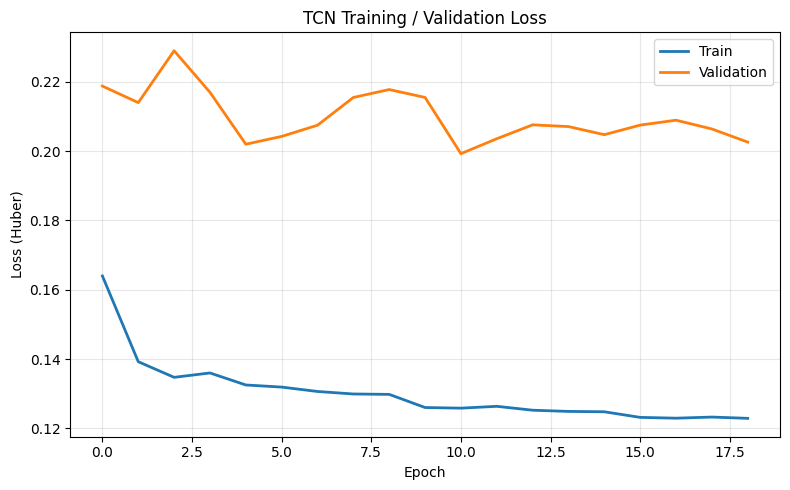

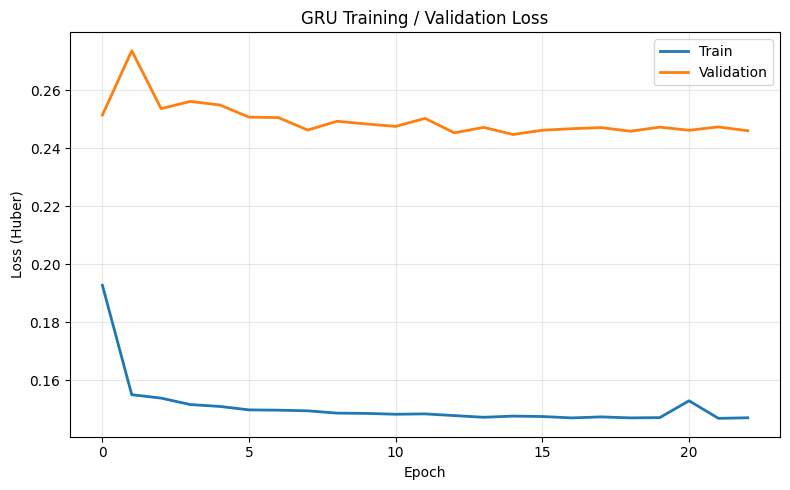

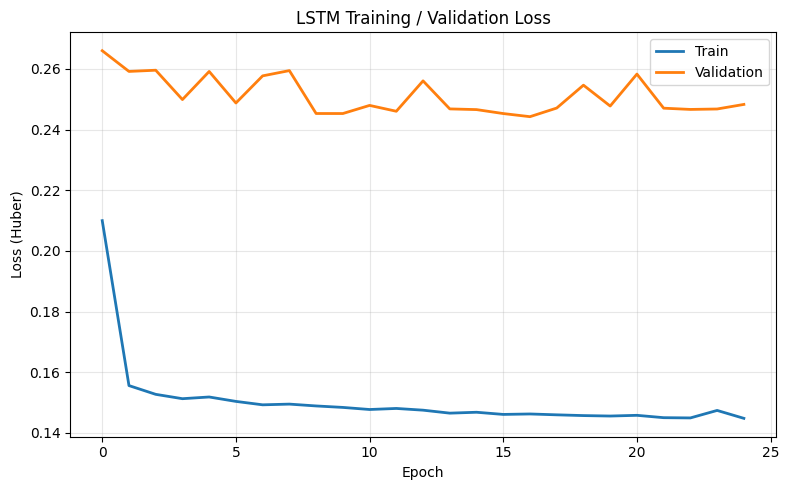


================ MODEL COMPARISON TABLE ================


,model,val_loss,rollout_rmse,sensitivity_score,conf_coverage,conf_width,mc_coverage,mc_width,best_uncertainty,final_score
0,TCN,0.199279,0.013810,0.081840,0.911187,0.047565,0.910401,0.047585,monte_carlo_resid,0.995657
1,LSTM,0.244257,0.014480,0.070049,0.904637,0.047314,0.906733,0.046941,conformal,0.558867
2,GRU,0.244710,0.014867,0.052533,0.910925,0.046989,0.904113,0.046403,monte_carlo_resid,0.196699



================ DOWNLOAD FILES ================


Button(button_style='success', description='Download TCN Loss PNG', icon='download', layout=Layout(width='250p…

Button(button_style='success', description='Download GRU Loss PNG', icon='download', layout=Layout(width='250p…

Button(button_style='success', description='Download LSTM Loss PNG', icon='download', layout=Layout(width='250…

Button(button_style='success', description='Download Comparison Table CSV', icon='download', layout=Layout(wid…


Best model selected: TCN
Selected uncertainty method: monte_carlo_resid
Interpretation:
- This model achieved the best weighted trade-off across rollout accuracy, sensitivity realism, and uncertainty quality.
- Phase 3 and Phase 4 will reuse this same trained model without retraining.


In [74]:
# ============================================================
# EXP CELL 6 - Final ranking, separate loss plots export, and winner
# - With manual download buttons (no auto-download)
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

rows = []

def uncertainty_method_score(cov, width, target=0.90):
    cov_term = max(0.0, 1.0 - abs(cov - target) / target)
    width_term = 1.0 / (1.0 + max(0.0, width))
    return 0.7 * cov_term + 0.3 * width_term

for name, res in exp_results.items():
    rmse = float(res["rollout_rmse"])
    sens = float(res["sensitivity_score"])

    uc = uncertainty_results[name]["conformal"]
    um = uncertainty_results[name]["monte_carlo_resid"]

    s_conf = uncertainty_method_score(uc["coverage"], uc["avg_width"], target=0.90)
    s_mc = uncertainty_method_score(um["coverage"], um["avg_width"], target=0.90)

    best_method = "conformal" if s_conf >= s_mc else "monte_carlo_resid"
    best_u_score = max(s_conf, s_mc)

    rows.append({
        "model": name,
        "rollout_rmse": rmse,
        "sensitivity_score": sens,
        "conf_coverage": uc["coverage"],
        "conf_width": uc["avg_width"],
        "mc_coverage": um["coverage"],
        "mc_width": um["avg_width"],
        "best_uncertainty": best_method,
        "best_u_score": best_u_score,
        "val_loss": float(experiment_models[name]["val_loss"]),
    })

score_df = pd.DataFrame(rows)

rmse_min, rmse_max = score_df["rollout_rmse"].min(), score_df["rollout_rmse"].max()
sens_min, sens_max = score_df["sensitivity_score"].min(), score_df["sensitivity_score"].max()

score_df["rmse_score"] = (
    (rmse_max - score_df["rollout_rmse"]) / (rmse_max - rmse_min)
    if rmse_max > rmse_min else 1.0
)

score_df["sens_score_norm"] = (
    (score_df["sensitivity_score"] - sens_min) / (sens_max - sens_min)
    if sens_max > sens_min else 1.0
)

score_df["final_score"] = (
    0.50 * score_df["rmse_score"] +
    0.30 * score_df["sens_score_norm"] +
    0.20 * score_df["best_u_score"]
)

score_df = score_df.sort_values("final_score", ascending=False).reset_index(drop=True)
model_comparison_df = score_df.copy()

# ============================================================
# Export folder
# ============================================================
output_dir = "exp_cell_6_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Small helper to create a download button
# ============================================================
def make_download_button(file_path, button_label):
    button = widgets.Button(
        description=button_label,
        button_style="success",
        icon="download",
        layout=widgets.Layout(width="250px")
    )

    def on_click(b):
        files.download(file_path)

    button.on_click(on_click)
    return button

# ============================================================
# Generate, save, display each loss plot separately
# ============================================================
model_order = ["TCN", "GRU", "LSTM"]
download_buttons = []

for model_name in model_order:
    hist = experiment_models[model_name]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist["train_loss_hist"], label="Train", linewidth=2)
    ax.plot(hist["val_loss_hist"], label="Validation", linewidth=2)
    ax.set_title(f"{model_name} Training / Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (Huber)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right")
    plt.tight_layout()

    png_path = os.path.join(output_dir, f"{model_name}_loss.png")
    fig.savefig(png_path, dpi=600, bbox_inches="tight")   # high quality PNG
    plt.show()
    plt.close(fig)

    download_buttons.append(
        make_download_button(png_path, f"Download {model_name} Loss PNG")
    )

# ============================================================
# Display and export comparison table
# ============================================================
print("\n================ MODEL COMPARISON TABLE ================")

table_to_export = score_df[[
    "model", "val_loss", "rollout_rmse", "sensitivity_score",
    "conf_coverage", "conf_width", "mc_coverage", "mc_width",
    "best_uncertainty", "final_score"
]]

display(table_to_export)

csv_path = os.path.join(output_dir, "model_comparison_table.csv")
table_to_export.to_csv(csv_path, index=False)

table_button = make_download_button(csv_path, "Download Comparison Table CSV")

# ============================================================
# Show all download buttons
# ============================================================
print("\n================ DOWNLOAD FILES ================")
for btn in download_buttons:
    display(btn)

display(table_button)

# ============================================================
# Winner
# ============================================================
winner = score_df.iloc[0]
best_model_name = str(winner["model"])
best_uncertainty_method = str(winner["best_uncertainty"])
best_model_info = experiment_models[best_model_name]

print(f"\nBest model selected: {best_model_name}")
print(f"Selected uncertainty method: {best_uncertainty_method}")
print("Interpretation:")
print("- This model achieved the best weighted trade-off across rollout accuracy, sensitivity realism, and uncertainty quality.")
print("- Phase 3 and Phase 4 will reuse this same trained model without retraining.")
print("=======================================================")

# Phase 3 - Deploy Best Model with Monte Carlo

This phase does not train any new network.
It directly reuses the Phase 2 winner, then runs:
- 20-step forecast simulation
- Evaluation workflow with the selected model only


In [17]:
# ============================================================
# PHASE 3 CELL 1 - Activate best Phase 2 model (no retraining)
# ============================================================

req = ["best_model_name", "experiment_models"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing objects {missing}. Run all Phase 2 experiment cells first.")

selected_model_entry = experiment_models[best_model_name]
model = selected_model_entry["model"]
selected_feature_mask = selected_model_entry["mask"]
selected_feature_names = selected_model_entry["feature_names"]

# Fixed request for this phase
FORECAST_STEPS = 20

print(f"Phase 3 active model: {best_model_name}")
print(f"Feature count: {len(selected_feature_names)}")
print(f"FORECAST_STEPS set to: {FORECAST_STEPS}")


Phase 3 active model: TCN
Feature count: 8
FORECAST_STEPS set to: 20


In [18]:
# =========================
# Helpers for DELTA method
# =========================

CUSH_IN_COL = "Cushion_in"  # must match your feature name
cush_in_idx = FEATURES.index(CUSH_IN_COL)

def delta_scaled_to_real(delta_scaled: float) -> float:
    return float(delta_scaler.inverse_transform([[delta_scaled]])[0, 0])

def cushion_real_to_input_scaled(cush_real: float) -> float:
    # Uses x_scaler because Cushion_in is part of FEATURES scaled by x_scaler
    # We transform only that one feature using the scaler parameters
    # RobustScaler: (x - center) / scale
    center = float(x_scaler.center_[cush_in_idx])
    scale = float(x_scaler.scale_[cush_in_idx])
    return (float(cush_real) - center) / scale


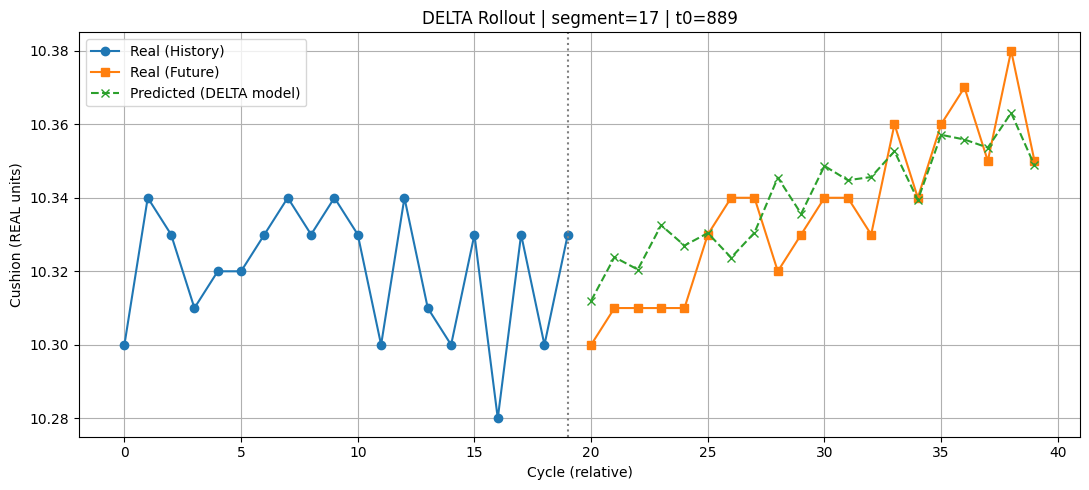

Button(button_style='success', description='Download PNG HQ', icon='download', style=ButtonStyle())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [73]:
# =========================
# Forecast plot (DELTA method)
# - Model predicts Delta_Cushion(t)
# - Reconstruct Cushion(t) = Cushion(t-1) + Delta_pred
# - Uses REAL future exogenous features from the same segment
# - Feeds back ONLY Cushion_in as predicted cushion
# - With download button for high-quality PNG
# =========================

import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

# Choose split you want to visualize:
DF_SCALED = df_test
DF_RAW    = df_test_raw
SEG_COL   = "segment"

FORECAST_STEPS = FORECAST_STEPS
HIST_PLOT = HIST_PLOT

# Pick a valid start point within one segment
valid = []
for seg_id, seg in DF_SCALED.groupby(SEG_COL):
    seg_len = len(seg)
    if seg_len > SEQ_LEN + FORECAST_STEPS + 1:
        valid.append(int(seg_id))

if not valid:
    raise RuntimeError("No segment long enough for forecast. Reduce FORECAST_STEPS or SEQ_LEN.")

seg_id = random.choice(valid)

seg_scaled = DF_SCALED[DF_SCALED[SEG_COL] == seg_id].reset_index(drop=True)
seg_raw    = DF_RAW[DF_RAW[SEG_COL] == seg_id].reset_index(drop=True)

# Choose t0 so we have history and future
t0_min = SEQ_LEN
t0_max = len(seg_scaled) - FORECAST_STEPS - 1
t0 = random.randint(t0_min, t0_max)

# Initial input sequence: rows [t0-SEQ_LEN ... t0-1]
seq = seg_scaled.loc[t0-SEQ_LEN:t0-1, FEATURES].values.astype(np.float32)

# Real cushion for plotting (history + future)
real_hist = seg_raw.loc[max(0, t0-HIST_PLOT):t0-1, TARGET_COL].values.astype(float)
real_fut  = seg_raw.loc[t0:t0+FORECAST_STEPS-1, TARGET_COL].values.astype(float)

# If history shorter than HIST_PLOT (near start), pad left
if len(real_hist) < HIST_PLOT:
    pad = [real_hist[0]] * (HIST_PLOT - len(real_hist))
    real_hist = np.concatenate([pad, real_hist])

# Start last known real cushion = cushion at time (t0-1)
last_cush_real = float(seg_raw.loc[t0-1, TARGET_COL])

preds_real = []

model.eval()
with torch.no_grad():
    for k in range(FORECAST_STEPS):
        x = torch.tensor(seq[np.newaxis], dtype=torch.float32).to(device)

        # Predict delta (scaled)
        pred_delta_scaled = float(model(x).item())
        pred_delta_real = delta_scaled_to_real(pred_delta_scaled)

        # Reconstruct cushion
        pred_cush_real = last_cush_real + pred_delta_real
        preds_real.append(pred_cush_real)

        # Next row uses REAL exogenous features at time (t0 + k)
        next_row = seg_scaled.loc[t0 + k, FEATURES].values.astype(np.float32)

        # Overwrite only Cushion_in with predicted cushion
        next_row[cush_in_idx] = cushion_real_to_input_scaled(pred_cush_real)

        # Roll forward
        seq[:-1] = seq[1:]
        seq[-1] = next_row

        # Update last cushion
        last_cush_real = pred_cush_real

# Plot
x_hist = np.arange(HIST_PLOT)
x_fut = np.arange(HIST_PLOT, HIST_PLOT + FORECAST_STEPS)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_hist, real_hist, label="Real (History)", marker="o")
ax.plot(x_fut, real_fut, label="Real (Future)", marker="s")
ax.plot(x_fut, np.array(preds_real), label="Predicted (DELTA model)", linestyle="--", marker="x")
ax.axvline(HIST_PLOT - 1, linestyle=":", color="gray")
ax.set_xlabel("Cycle (relative)")
ax.set_ylabel("Cushion (REAL units)")
ax.set_title(f"DELTA Rollout | segment={seg_id} | t0={t0}")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

# Save figure in high quality
file_name = f"delta_rollout_segment_{seg_id}_t0_{t0}.png"
fig.savefig(file_name, dpi=600, bbox_inches="tight")

# Download button
download_button = widgets.Button(
    description="Download PNG HQ",
    button_style="success",
    icon="download"
)

def download_figure(b):
    files.download(file_name)

download_button.on_click(download_figure)

display(download_button)

In [20]:
# ============================================================
# CELL 1 — MONTE CARLO CONFIG (recipe-based, calibrated to TEST)
# ============================================================

# ---- Specs (REAL units)
TARGET_CUSHION = 10.33
LSL_DEV = -0.3
USL_DEV = +0.3

LSL = TARGET_CUSHION + LSL_DEV
USL = TARGET_CUSHION + USL_DEV
assert USL > LSL, "USL must be > LSL"

# ---- Recipe setpoints (REAL units)
# Option 1: keep manual recipe (uncomment and fill)
RECIPE_REAL = {
    "Back_pressure_ActValue": 68.00,
    "Maximum_Injection_Pressure": 1500.0,
    "Switch_Over_Pressure": 1500.0,
    "SwitchOver_volume_ActValue": 13.0,
    "Dosing_Volume_ActValue": 89.0,
    "Injection_Time": 1.0,
    "Dosing_Time": 2.3,
}
# ============================================================
# Features treated as recipe-fixed (no stochastic variation)
# ============================================================

FROZEN_FEATURES = [

]

# Option 2: use TEST means (recommended for fair comparison)
# (requires df_test_raw)
# recipe_keys = list(RECIPE_REAL.keys())
# RECIPE_REAL = {k: float(df_test_raw[k].astype(float).mean()) for k in recipe_keys if k in df_test_raw.columns}

# ---- Simulation settings
N_SIMS     = 1000
SIM_CYCLES = 80
BURN_IN    = 30
assert SIM_CYCLES > BURN_IN, "SIM_CYCLES must be > BURN_IN"

# ---- Noise settings (keep 1.0 for calibration vs REAL test SPC)
NOISE_SCALE = 1.0

# Debug toggles (use to isolate issues)
USE_FEATURE_NOISE   = True
USE_RESIDUAL_NOISE  = True

# Better residual model (recommended)
USE_EMPIRICAL_RESID = True      # sample from residual_pool (if available)
USE_AR1_RESIDUAL    = True      # correlated noise
AR1_RHO             = 0.85

# Safety / physics (recommended)
USE_DELTA_CLAMP   = True        # clamp delta noise to avoid random-walk blowups
DELTA_CLAMP_Q     = 0.995       # quantile used for clamp threshold (from residuals)
USE_CUSHION_CLAMP = False
CUSH_MIN, CUSH_MAX = 9.0, 12.0

# Initial cushion
INIT_MODE = "test_mean"         # "test_mean" | "train_mean" | "last_train" | "custom"
INIT_CUSHION_REAL = None


In [21]:
# ============================================================
# CELL 2 — Helper + Feature noise (from TEST local or TEST global)
# (feature noise is NOT your main issue, but keep it realistic)
# ============================================================

import numpy as np
import pandas as pd

def compute_cp_cpk(samples, lsl, usl):
    samples = np.asarray(samples, dtype=float)
    mu = float(np.mean(samples))
    sigma = float(np.std(samples, ddof=1))
    if sigma <= 1e-12:
        return {"mu": mu, "sigma": sigma, "Cp": np.inf, "Cpk": np.inf,
                "P_out": float(np.mean((samples < lsl) | (samples > usl)))}
    cp = (usl - lsl) / (6.0 * sigma)
    cpk = min((usl - mu) / (3.0 * sigma), (mu - lsl) / (3.0 * sigma))
    p_out = float(np.mean((samples < lsl) | (samples > usl)))
    return {"mu": mu, "sigma": sigma, "Cp": float(cp), "Cpk": float(cpk), "P_out": p_out}

# ---- required
required = ["FEATURES", "TARGET_COL", "df_train_raw", "cush_in_idx"]
missing = [r for r in required if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

HAS_TEST = "df_test_raw" in globals()
if not HAS_TEST:
    print("Warning: df_test_raw not found. Feature noise will be estimated from TRAIN.")
CUSH_IN_COL = FEATURES[cush_in_idx]

# Features to noise (exclude target; cushion input noise forced to 0 later)
feat_cols = [c for c in FEATURES if c != TARGET_COL]

def make_local_mask(df, recipe_dict, rel_tol=0.02):
    mask = np.ones(len(df), dtype=bool)
    for k, v in recipe_dict.items():
        if k in df.columns:
            v = float(v)
            lo, hi = v * (1 - rel_tol), v * (1 + rel_tol)
            x = df[k].astype(float).values
            mask &= (x >= lo) & (x <= hi)
    return mask

# ---- choose dataset for sigma: TEST preferred (for matching Real SPC)
df_src = df_test_raw if HAS_TEST else df_train_raw

# ---- local subset around recipe (if enough rows), else fallback to global
REL_TOL = 0.02  # 2% (increase if too few local rows)
mask_local = make_local_mask(df_src, RECIPE_REAL, rel_tol=REL_TOL)
df_local = df_src.loc[mask_local]

use_local = len(df_local) >= 200
df_sigma = df_local if use_local else df_src
print(f"[feature_sigma] using {'LOCAL' if use_local else 'GLOBAL'} on {'TEST' if HAS_TEST else 'TRAIN'} | n={len(df_sigma)} | REL_TOL={REL_TOL*100:.1f}%")

feature_sigma = {}
for c in feat_cols:
    if c in df_sigma.columns:
        feature_sigma[c] = float(df_sigma[c].astype(float).std(ddof=1))
    else:
        feature_sigma[c] = 0.0


# Optional: set recipe-setpoint-like features to zero noise if you want a strict recipe scenario
# for k in RECIPE_REAL.keys():
#     if k in feature_sigma:
#         feature_sigma[k] = 0.0

print("feature_sigma (first 10):", dict(list(feature_sigma.items())[:10]))


[feature_sigma] using GLOBAL on TEST | n=3867 | REL_TOL=2.0%
feature_sigma (first 10): {'Maximum_Injection_Pressure': 41.56591520524299, 'Switch_Over_Pressure': 41.181922460158404, 'Injection_Time': 0.00047743051344913167, 'Dosing_Time': 0.01889495087736278, 'Back_pressure_ActValue': 0.660497331880706, 'SwitchOver_volume_ActValue': 0.004820464426362341, 'Dosing_Volume_ActValue': 0.003814800224906003, 'Cushion_in': 0.02355137084082595}


In [22]:
# ============================================================
# CELL 3 — Residual calibration on TEST via DataLoader
# (works when y_test array is NOT available)
# ============================================================

import numpy as np
import torch

# ---- required
req = ["model", "device", "delta_scaler"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing: {missing}")

# choose loader: prefer test_loader, fallback to val_loader
if "test_loader" in globals():
    loader = test_loader
    loader_name = "test_loader"
elif "val_loader" in globals():
    loader = val_loader
    loader_name = "val_loader"
else:
    raise RuntimeError("Neither test_loader nor val_loader found")

model.eval()
pred_list, true_list = [], []

with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        preds = model(xb)

        # ensure shape (B,1)
        if preds.ndim == 1:
            preds = preds.unsqueeze(1)
        if yb.ndim == 1:
            yb = yb.unsqueeze(1)

        # one-step only
        p1 = preds[:, 0].detach().cpu().numpy().reshape(-1, 1)
        t1 = yb[:, 0].detach().cpu().numpy().reshape(-1, 1)

        pred_real = delta_scaler.inverse_transform(p1).ravel().astype(np.float32)
        true_real = delta_scaler.inverse_transform(t1).ravel().astype(np.float32)

        pred_list.append(pred_real)
        true_list.append(true_real)

pred_real = np.concatenate(pred_list)
true_real = np.concatenate(true_list)

residual_pool = (true_real - pred_real).astype(np.float32)

sigma_res = float(np.std(residual_pool, ddof=1))
bias_res  = float(np.mean(residual_pool))

print(f"[{loader_name} residual calibration]")
print(f"  sigma_res = {sigma_res:.6f}")
print(f"  bias_res  = {bias_res:.6f}")
print(f"  n         = {len(residual_pool)}")

# ---- clamp threshold (prevents MC random walk explosion)
DELTA_CLAMP_Q = 0.995
delta_clamp_abs = float(np.quantile(np.abs(residual_pool), DELTA_CLAMP_Q))
print(f"[delta clamp] |Δ| @ q={DELTA_CLAMP_Q}: {delta_clamp_abs:.6f}")

# ---- optional sanity check vs real TEST delta
if "df_test_raw" in globals() and TARGET_COL in df_test_raw.columns:
    std_test_delta = float(df_test_raw[TARGET_COL].astype(float).diff().dropna().std(ddof=1))
    print(f"[sanity] std(ΔC_real test) = {std_test_delta:.6f}")


[val_loader residual calibration]
  sigma_res = 0.133210
  bias_res  = -0.003891
  n         = 3842
[delta clamp] |Δ| @ q=0.995: 0.104889
[sanity] std(ΔC_real test) = 0.023704


In [23]:
# ============================================================
# CELL 4 — FAST Monte Carlo (batched) using calibrated residual noise
# Produces: runs (after burn-in), stats printed
# ============================================================

import numpy as np
import torch

req = ["x_scaler", "delta_scaler", "model", "device", "FEATURES", "cush_in_idx",
       "df_train_raw", "TARGET_COL", "SEQ_LEN",
       "feature_sigma", "sigma_res", "bias_res", "residual_pool",
       "LSL", "USL",
       "N_SIMS", "SIM_CYCLES", "BURN_IN",
       "USE_FEATURE_NOISE", "USE_RESIDUAL_NOISE", "USE_EMPIRICAL_RESID",
       "USE_AR1_RESIDUAL", "AR1_RHO", "NOISE_SCALE",
       "USE_DELTA_CLAMP", "delta_clamp_abs",
       "INIT_MODE"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects for MC: {missing}")

n_runs = int(N_SIMS)
steps  = int(SIM_CYCLES)
seq_len = int(SEQ_LEN)
n_feat = len(FEATURES)

# ---------- fast scaling (StandardScaler-like)
_x_mean  = getattr(x_scaler, "mean_", None)
_x_scale = getattr(x_scaler, "scale_", None)

def scale_x_fast(x_real: np.ndarray) -> np.ndarray:
    if _x_mean is not None and _x_scale is not None:
        return ((x_real - _x_mean) / _x_scale).astype(np.float32)
    import pandas as pd
    shp = x_real.shape
    x2 = x_real.reshape(-1, shp[-1])
    x2s = x_scaler.transform(pd.DataFrame(x2, columns=FEATURES)).astype(np.float32)
    return x2s.reshape(*shp)

# ---------- delta inverse scaling
_d_mean  = float(getattr(delta_scaler, "mean_", [0.0])[0])
_d_scale = float(getattr(delta_scaler, "scale_", [1.0])[0])

def delta_scaled_to_real_fast(d_scaled: np.ndarray) -> np.ndarray:
    return d_scaled * _d_scale + _d_mean

# ---------- pick initial cushion
if INIT_MODE == "test_mean":
    if "df_test_raw" not in globals():
        raise RuntimeError("INIT_MODE='test_mean' requires df_test_raw")
    C0_real = float(df_test_raw[TARGET_COL].astype(float).mean())
elif INIT_MODE == "train_mean":
    C0_real = float(df_train_raw[TARGET_COL].astype(float).mean())
elif INIT_MODE == "last_train":
    i0 = df_train_raw.index[-1]
    C0_real = float(df_train_raw.loc[i0, TARGET_COL])
elif INIT_MODE == "custom":
    if INIT_CUSHION_REAL is None:
        raise ValueError("INIT_CUSHION_REAL must be set when INIT_MODE='custom'")
    C0_real = float(INIT_CUSHION_REAL)
else:
    raise ValueError("INIT_MODE must be: test_mean | train_mean | last_train | custom")

# ---------- base recipe row aligned with FEATURES
base_row_real = np.zeros((n_feat,), dtype=np.float32)
for i, f in enumerate(FEATURES):
    if f == FEATURES[cush_in_idx]:
        base_row_real[i] = float(C0_real)  # will be overwritten in seq anyway
    elif f in RECIPE_REAL:
        base_row_real[i] = float(RECIPE_REAL[f])
    else:
        # fallback: use train mean if feature isn't specified
        if f in df_train_raw.columns:
            base_row_real[i] = float(df_train_raw[f].astype(float).mean())
        else:
            base_row_real[i] = 0.0

# ---------- sigma vector aligned with FEATURES
sigma_vec = np.array([float(feature_sigma.get(f, 0.0)) for f in FEATURES], dtype=np.float32)
sigma_vec[cush_in_idx] = 0.0
sigma_vec *= float(NOISE_SCALE)

use_feat = bool(USE_FEATURE_NOISE) and np.any(sigma_vec > 0)
use_res  = bool(USE_RESIDUAL_NOISE) and (float(sigma_res) > 0)

# ---------- initial sequence: (n_runs, seq_len, n_feat)
seq_real = np.tile(base_row_real, (n_runs, seq_len, 1)).astype(np.float32)
seq_real[:, :, cush_in_idx] = float(C0_real)

if use_feat:
    seq_real += np.random.normal(0.0, sigma_vec, size=(n_runs, seq_len, n_feat)).astype(np.float32)

seq_scaled_np = scale_x_fast(seq_real)
seq_scaled = torch.from_numpy(seq_scaled_np).to(device=device, dtype=torch.float32)

# states
C_prev = torch.full((n_runs,), float(C0_real), device=device, dtype=torch.float32)
traj_full = np.empty((n_runs, steps), dtype=np.float32)
base_row_batch = np.tile(base_row_real, (n_runs, 1)).astype(np.float32)

# residual AR state
e_prev = np.zeros((n_runs,), dtype=np.float32)

model.eval()
with torch.no_grad():
    for k in range(steps):
        # model batched forward
        pred_delta_scaled = model(seq_scaled).squeeze(-1)
        pred_delta_scaled_np = pred_delta_scaled.detach().cpu().numpy().astype(np.float32)

        # inverse scale delta
        pred_delta_real_np = delta_scaled_to_real_fast(pred_delta_scaled_np)

        # bias correction (prevents drift)
        pred_delta_real_np += float(bias_res)

        # residual noise injection
        if use_res:
            if USE_EMPIRICAL_RESID and (residual_pool is not None) and (len(residual_pool) > 100):
                e = np.random.choice(residual_pool, size=n_runs, replace=True).astype(np.float32)
            else:
                e = np.random.normal(0.0, float(sigma_res), size=(n_runs,)).astype(np.float32)

            e *= float(NOISE_SCALE)

            if USE_AR1_RESIDUAL:
                rho = float(AR1_RHO)
                e = rho * e_prev + np.sqrt(max(1e-8, 1.0 - rho*rho)) * e
                e_prev = e

            pred_delta_real_np += e

        # clamp delta
        if USE_DELTA_CLAMP and (delta_clamp_abs is not None):
            clamp_abs = float(delta_clamp_abs) * float(NOISE_SCALE)
            pred_delta_real_np = np.clip(pred_delta_real_np, -clamp_abs, +clamp_abs)

        pred_delta_real = torch.from_numpy(pred_delta_real_np).to(device=device, dtype=torch.float32)

        # update cushion
        C_next = C_prev + pred_delta_real
        if USE_CUSHION_CLAMP:
            C_next = torch.clamp(C_next, float(CUSH_MIN), float(CUSH_MAX))

        traj_full[:, k] = C_next.detach().cpu().numpy()

        # next row real
        next_row_real = base_row_batch.copy()
        if use_feat:
            next_row_real += np.random.normal(0.0, sigma_vec, size=(n_runs, n_feat)).astype(np.float32)
        next_row_real[:, cush_in_idx] = traj_full[:, k]

        # scale and roll
        next_row_scaled_np = scale_x_fast(next_row_real)
        next_row_scaled = torch.from_numpy(next_row_scaled_np).to(device=device, dtype=torch.float32)

        seq_scaled[:, :-1, :] = seq_scaled[:, 1:, :]
        seq_scaled[:, -1, :] = next_row_scaled

        C_prev = C_next

# burn-in discard
runs = traj_full[:, BURN_IN:] if BURN_IN > 0 else traj_full

samples = runs.reshape(-1)
stats = compute_cp_cpk(samples, LSL, USL)

print("========== Virtual SPC / Predictive Capability (ABSOLUTE Cushion) ==========")
print(f"Runs x cycles: {runs.shape[0]} x {runs.shape[1]}  (burn-in={BURN_IN})")
print(f"Mean (mu):     {stats['mu']:.4f}")
print(f"Std  (sigma):  {stats['sigma']:.4f}")
print(f"Cp:            {stats['Cp']:.4f}")
print(f"Cpk:           {stats['Cpk']:.4f}")
print(f"P(out of spec):{stats['P_out']*100:.2f}%")
print("===========================================================================")


========== Virtual SPC / Predictive Capability (ABSOLUTE Cushion) ==========
Runs x cycles: 1000 x 50  (burn-in=30)
Mean (mu):     10.3268
Std  (sigma):  0.0632
Cp:            1.5828
Cpk:           1.5661
P(out of spec):1.07%


In [24]:
# ============================================================
# CELL 4b — Plausibility-based filtering of Monte Carlo runs
# (Exclude run-away trajectories for typical capability analysis)
# ============================================================

import numpy as np

req = ["runs", "TARGET_CUSHION", "LSL", "USL", "compute_cp_cpk"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

# ------------------------------------------------------------
# Define physical / operational plausibility band
# (NOT specs — wider than specs, narrower than stress-test)
# ------------------------------------------------------------
PL_LOW  = TARGET_CUSHION - 0.4
PL_HIGH = TARGET_CUSHION + 0.4

# ------------------------------------------------------------
# Keep only runs that NEVER leave plausibility band
# ------------------------------------------------------------
good_runs_mask = np.all((runs >= PL_LOW) & (runs <= PL_HIGH), axis=1)
runs_good = runs[good_runs_mask]

print("========== Plausibility Filter ==========")
print(f"Kept runs: {runs_good.shape[0]} / {runs.shape[0]} "
      f"({100 * runs_good.shape[0] / runs.shape[0]:.2f}%)")
print(f"Discarded runs (run-away): {runs.shape[0] - runs_good.shape[0]}")
print("Plausibility band:", PL_LOW, "→", PL_HIGH)
print("========================================")

# ------------------------------------------------------------
# Compute Cpk on filtered runs (typical behavior)
# ------------------------------------------------------------
samples_good = runs_good.reshape(-1)
stats_good = compute_cp_cpk(samples_good, LSL, USL)

print("========== Typical Capability (Filtered) ==========")
print(f"Mean (mu):     {stats_good['mu']:.4f}")
print(f"Std  (sigma):  {stats_good['sigma']:.4f}")
print(f"Cp:            {stats_good['Cp']:.4f}")
print(f"Cpk:           {stats_good['Cpk']:.4f}")
print(f"P(out of spec):{stats_good['P_out']*100:.2f}%")
print("===================================================")


========== Plausibility Filter ==========
Kept runs: 937 / 1000 (93.70%)
Discarded runs (run-away): 63
Plausibility band: 9.93 → 10.73
========== Typical Capability (Filtered) ==========
Mean (mu):     10.3325
Std  (sigma):  0.0286
Cp:            3.5014
Cpk:           3.4724
P(out of spec):0.02%


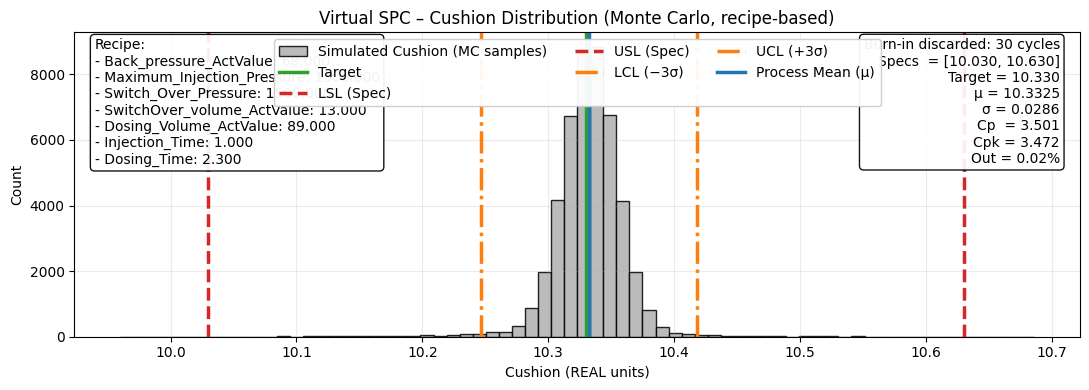

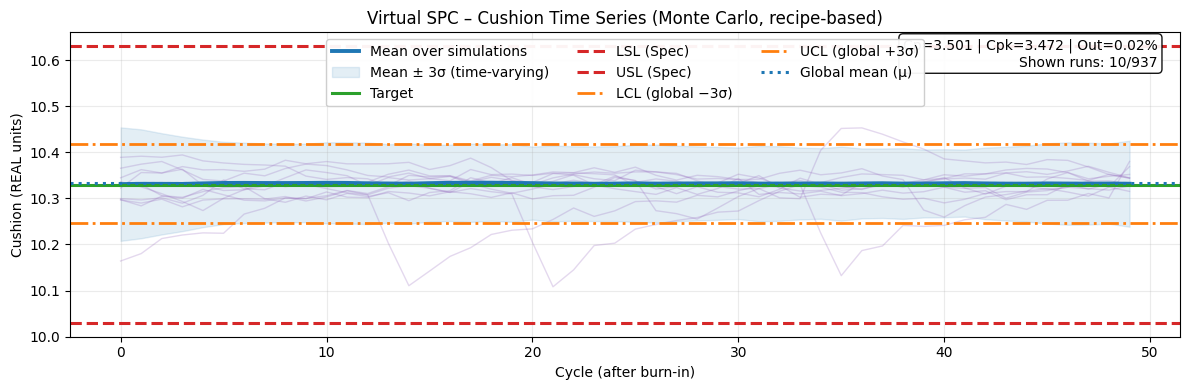


================ DOWNLOAD FIGURES ================


Button(button_style='success', description='Download Histogram PNG', icon='download', layout=Layout(width='280…

Button(button_style='success', description='Download Time Series PNG', icon='download', layout=Layout(width='2…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
# ============================================================
# CELL 5 — Virtual SPC plots (Monte Carlo simulation, recipe-based) + COLORS
# - With manual download buttons for high-quality PNG
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

req = ["runs", "LSL", "USL", "compute_cp_cpk", "TARGET_CUSHION", "RECIPE_REAL", "BURN_IN"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

runs = np.asarray(runs_good, dtype=float)
samples = runs.reshape(-1)

results = compute_cp_cpk(samples, LSL, USL)
mu_real = results["mu"]
sigma_real = results["sigma"]
Cp = results["Cp"]
Cpk = results["Cpk"]
P_out = results["P_out"]

LCL_REAL = mu_real - 3.0 * sigma_real
UCL_REAL = mu_real + 3.0 * sigma_real

# ============================================================
# Export folder
# ============================================================
output_dir = "cell_5_spc_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Helper for download button
# ============================================================
def make_download_button(file_path, button_label):
    button = widgets.Button(
        description=button_label,
        button_style="success",
        icon="download",
        layout=widgets.Layout(width="280px")
    )

    def on_click(b):
        files.download(file_path)

    button.on_click(on_click)
    return button

# ---- Colors
COL_HIST   = "#B0B0B0"
COL_TARGET = "#2CA02C"
COL_SPEC   = "#D62728"
COL_CTRL   = "#FF7F0E"
COL_MEAN   = "#1F77B4"
COL_RUN    = "#9467BD"
COL_BAND   = "#1F77B4"

recipe_text = "Recipe:\n" + "\n".join([f"- {k}: {v:.3f}" for k, v in RECIPE_REAL.items()])

# ----------------------------
# 1) Histogram
# ----------------------------
fig1, ax1 = plt.subplots(figsize=(11, 4))

ax1.hist(samples, bins=70, color=COL_HIST, edgecolor="black", alpha=0.85, label="Simulated Cushion (MC samples)")

ax1.axvline(TARGET_CUSHION, color=COL_TARGET, linestyle="-",  linewidth=2.5, label="Target")
ax1.axvline(LSL,            color=COL_SPEC,   linestyle="--", linewidth=2.5, label="LSL (Spec)")
ax1.axvline(USL,            color=COL_SPEC,   linestyle="--", linewidth=2.5, label="USL (Spec)")
ax1.axvline(LCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.5, label="LCL (−3σ)")
ax1.axvline(UCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.5, label="UCL (+3σ)")
ax1.axvline(mu_real,        color=COL_MEAN,   linestyle="-",  linewidth=2.5, label="Process Mean (µ)")

ax1.set_title("Virtual SPC – Cushion Distribution (Monte Carlo, recipe-based)")
ax1.set_xlabel("Cushion (REAL units)")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.25)

ax1.text(
    0.98, 0.98,
    (
        f"Burn-in discarded: {BURN_IN} cycles\n"
        f"Specs  = [{LSL:.3f}, {USL:.3f}]\n"
        f"Target = {TARGET_CUSHION:.3f}\n"
        f"µ = {mu_real:.4f}\n"
        f"σ = {sigma_real:.4f}\n"
        f"Cp  = {Cp:.3f}\n"
        f"Cpk = {Cpk:.3f}\n"
        f"Out = {P_out*100:.2f}%"
    ),
    transform=ax1.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92)
)

ax1.text(
    0.02, 0.98,
    recipe_text,
    transform=ax1.transAxes,
    ha="left", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92)
)

ax1.legend(loc="upper center", ncol=3, framealpha=0.95)
plt.tight_layout()
plt.show()

hist_path = os.path.join(output_dir, "virtual_spc_histogram.png")
fig1.savefig(hist_path, dpi=600, bbox_inches="tight")
plt.close(fig1)

# ----------------------------
# 2) Time series (multi-run + mean + band)
# ----------------------------
fig2, ax2 = plt.subplots(figsize=(12, 4))

n_runs, n_cycles = runs.shape
x = np.arange(n_cycles)

n_show = min(10, n_runs)
for i in range(n_show):
    ax2.plot(runs[i], color=COL_RUN, alpha=0.25, linewidth=1)

mean_path = runs.mean(axis=0)
std_path  = runs.std(axis=0, ddof=1)

ax2.plot(mean_path, color=COL_MEAN, linewidth=2.8, label="Mean over simulations")

ax2.fill_between(
    x, mean_path - 3*std_path, mean_path + 3*std_path,
    color=COL_BAND, alpha=0.12, label="Mean ± 3σ (time-varying)"
)

ax2.axhline(TARGET_CUSHION, color=COL_TARGET, linestyle="-",  linewidth=2.2, label="Target")
ax2.axhline(LSL,            color=COL_SPEC,   linestyle="--", linewidth=2.2, label="LSL (Spec)")
ax2.axhline(USL,            color=COL_SPEC,   linestyle="--", linewidth=2.2, label="USL (Spec)")
ax2.axhline(LCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.0, label="LCL (global −3σ)")
ax2.axhline(UCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.0, label="UCL (global +3σ)")
ax2.axhline(mu_real,        color=COL_MEAN,   linestyle=":",  linewidth=2.2, label="Global mean (µ)")

ax2.set_title("Virtual SPC – Cushion Time Series (Monte Carlo, recipe-based)")
ax2.set_xlabel("Cycle (after burn-in)")
ax2.set_ylabel("Cushion (REAL units)")
ax2.grid(True, alpha=0.25)

ax2.text(
    0.98, 0.98,
    f"Cp={Cp:.3f} | Cpk={Cpk:.3f} | Out={P_out*100:.2f}%\nShown runs: {n_show}/{n_runs}",
    transform=ax2.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92)
)

ax2.legend(loc="upper center", ncol=3, framealpha=0.95)
plt.tight_layout()
plt.show()

ts_path = os.path.join(output_dir, "virtual_spc_time_series.png")
fig2.savefig(ts_path, dpi=600, bbox_inches="tight")
plt.close(fig2)

# ============================================================
# Download buttons
# ============================================================
print("\n================ DOWNLOAD FIGURES ================")
display(make_download_button(hist_path, "Download Histogram PNG"))
display(make_download_button(ts_path, "Download Time Series PNG"))

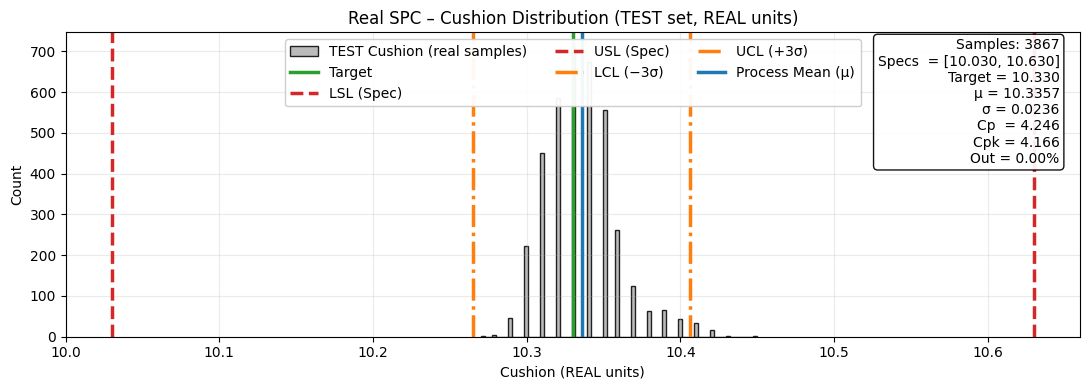

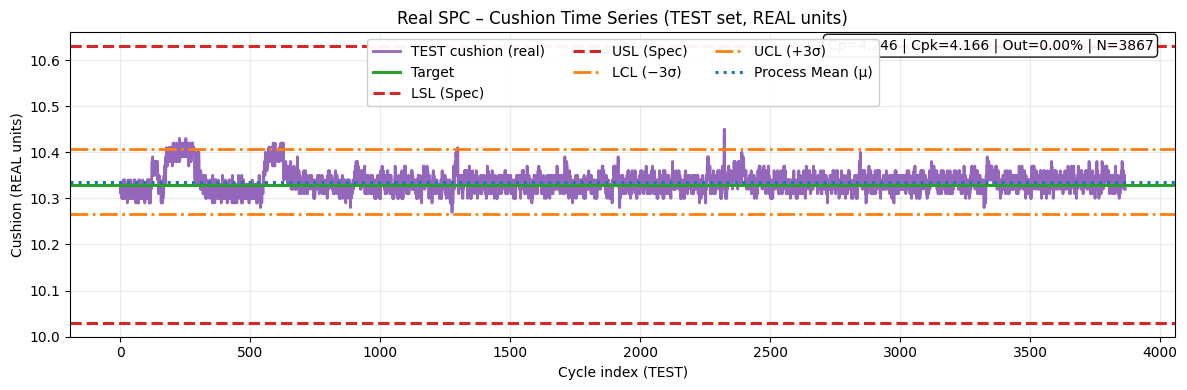


================ DOWNLOAD FIGURES ================


Button(button_style='success', description='Download Real SPC Histogram PNG', icon='download', layout=Layout(w…

Button(button_style='success', description='Download Real SPC Time Series PNG', icon='download', layout=Layout…

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [78]:
# ============================================================
# NEW CELL — "Real SPC" plots for TEST set (same style as Cell 5)
# Uses df_test_raw[TARGET_COL] as the real cushion series
# - With manual download buttons for high-quality PNG
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

req = ["df_test_raw", "TARGET_COL", "LSL", "USL", "compute_cp_cpk", "TARGET_CUSHION"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

# ============================================================
# Export folder
# ============================================================
output_dir = "real_spc_test_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Helper for download button
# ============================================================
def make_download_button(file_path, button_label):
    button = widgets.Button(
        description=button_label,
        button_style="success",
        icon="download",
        layout=widgets.Layout(width="280px")
    )

    def on_click(b):
        files.download(file_path)

    button.on_click(on_click)
    return button

# ---- real cushion series from TEST (REAL units)
test_series = df_test_raw[TARGET_COL].astype(float).dropna().values
samples = test_series.copy()

# ---- stats
results = compute_cp_cpk(samples, LSL, USL)
mu_real = results["mu"]
sigma_real = results["sigma"]
Cp = results["Cp"]
Cpk = results["Cpk"]
P_out = results["P_out"]

LCL_REAL = mu_real - 3.0 * sigma_real
UCL_REAL = mu_real + 3.0 * sigma_real

# ---- Colors (same palette as Cell 5)
COL_HIST   = "#B0B0B0"
COL_TARGET = "#2CA02C"
COL_SPEC   = "#D62728"
COL_CTRL   = "#FF7F0E"
COL_MEAN   = "#1F77B4"
COL_SERIES = "#9467BD"

# ============================================================
# 1) Histogram — REAL TEST cushion distribution
# ============================================================
fig1, ax1 = plt.subplots(figsize=(11, 4))

ax1.hist(samples, bins=70, color=COL_HIST, edgecolor="black", alpha=0.85, label="TEST Cushion (real samples)")

ax1.axvline(TARGET_CUSHION, color=COL_TARGET, linestyle="-",  linewidth=2.5, label="Target")
ax1.axvline(LSL,            color=COL_SPEC,   linestyle="--", linewidth=2.5, label="LSL (Spec)")
ax1.axvline(USL,            color=COL_SPEC,   linestyle="--", linewidth=2.5, label="USL (Spec)")
ax1.axvline(LCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.5, label="LCL (−3σ)")
ax1.axvline(UCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.5, label="UCL (+3σ)")
ax1.axvline(mu_real,        color=COL_MEAN,   linestyle="-",  linewidth=2.5, label="Process Mean (µ)")

ax1.set_title("Real SPC – Cushion Distribution (TEST set, REAL units)")
ax1.set_xlabel("Cushion (REAL units)")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.25)

ax1.text(
    0.98, 0.98,
    (
        f"Samples: {len(samples)}\n"
        f"Specs  = [{LSL:.3f}, {USL:.3f}]\n"
        f"Target = {TARGET_CUSHION:.3f}\n"
        f"µ = {mu_real:.4f}\n"
        f"σ = {sigma_real:.4f}\n"
        f"Cp  = {Cp:.3f}\n"
        f"Cpk = {Cpk:.3f}\n"
        f"Out = {P_out*100:.2f}%"
    ),
    transform=ax1.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92)
)

ax1.legend(loc="upper center", ncol=3, framealpha=0.95)
plt.tight_layout()
plt.show()

hist_path = os.path.join(output_dir, "real_spc_test_histogram.png")
fig1.savefig(hist_path, dpi=600, bbox_inches="tight")
plt.close(fig1)

# ============================================================
# 2) Time series — REAL TEST cushion
# ============================================================
fig2, ax2 = plt.subplots(figsize=(12, 4))

ax2.plot(test_series, color=COL_SERIES, linewidth=2, label="TEST cushion (real)")

ax2.axhline(TARGET_CUSHION, color=COL_TARGET, linestyle="-",  linewidth=2.2, label="Target")
ax2.axhline(LSL,            color=COL_SPEC,   linestyle="--", linewidth=2.2, label="LSL (Spec)")
ax2.axhline(USL,            color=COL_SPEC,   linestyle="--", linewidth=2.2, label="USL (Spec)")
ax2.axhline(LCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.0, label="LCL (−3σ)")
ax2.axhline(UCL_REAL,       color=COL_CTRL,   linestyle="-.", linewidth=2.0, label="UCL (+3σ)")
ax2.axhline(mu_real,        color=COL_MEAN,   linestyle=":",  linewidth=2.2, label="Process Mean (µ)")

ax2.set_title("Real SPC – Cushion Time Series (TEST set, REAL units)")
ax2.set_xlabel("Cycle index (TEST)")
ax2.set_ylabel("Cushion (REAL units)")
ax2.grid(True, alpha=0.25)

ax2.text(
    0.98, 0.98,
    f"Cp={Cp:.3f} | Cpk={Cpk:.3f} | Out={P_out*100:.2f}% | N={len(samples)}",
    transform=ax2.transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.92)
)

ax2.legend(loc="upper center", ncol=3, framealpha=0.95)
plt.tight_layout()
plt.show()

ts_path = os.path.join(output_dir, "real_spc_test_time_series.png")
fig2.savefig(ts_path, dpi=600, bbox_inches="tight")
plt.close(fig2)

# ============================================================
# Download buttons
# ============================================================
print("\n================ DOWNLOAD FIGURES ================")
display(make_download_button(hist_path, "Download Real SPC Histogram PNG"))
display(make_download_button(ts_path, "Download Real SPC Time Series PNG"))


================ DIGITAL TWIN COMPATIBILITY (W=50) ================
Cushion values (C):
  MC:   mu=10.3318, sigma=0.0294, P5=10.2934, P95=10.3682
  TEST: mu=10.3344, sigma=0.0224, P5=10.3000, P95=10.3700
  Effect size (Cohen's d) on C values: -0.100  (|d|<0.2 small, <0.5 medium)
  KS test on C values: D=0.106, p=0.0000

Dynamics (ΔC):
  MC:   mu=-0.00003, sigma=0.01457, P5=-0.02043, P95=0.02130
  TEST: mu=-0.00002, sigma=0.02368, P5=-0.04000, P95=0.04000
  Effect size (Cohen's d) on ΔC: -0.000
  KS test on ΔC: D=0.238, p=0.0000

Envelope coverage (MC 5–95% band vs TEST windows):
  Point-wise coverage: 91.71%  (target ~90% if well calibrated)
  Window fully-covered: 26.00% (strict criterion)

Practical interpretation:
  - If mean/std and ΔC std are close, and coverage ≈ 90%, the simulation is consistent with TEST regime.
  - Large gaps in ΔC sigma or low coverage indicate mismatch in dynamics/noise assumptions.



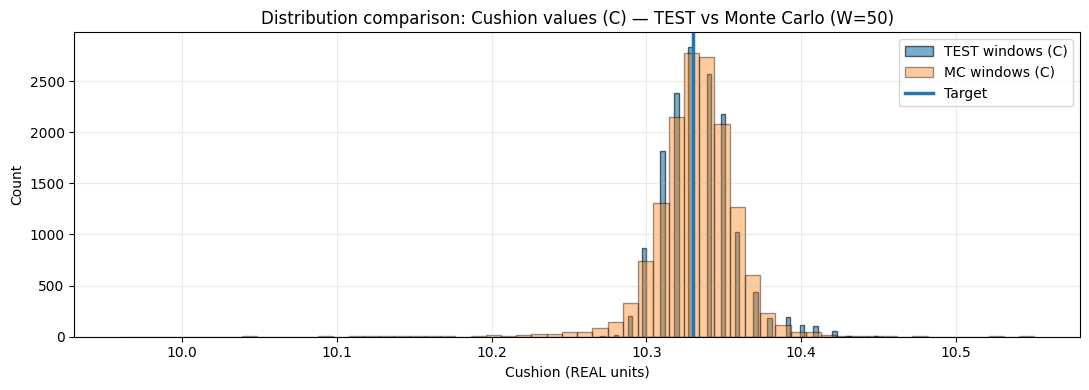

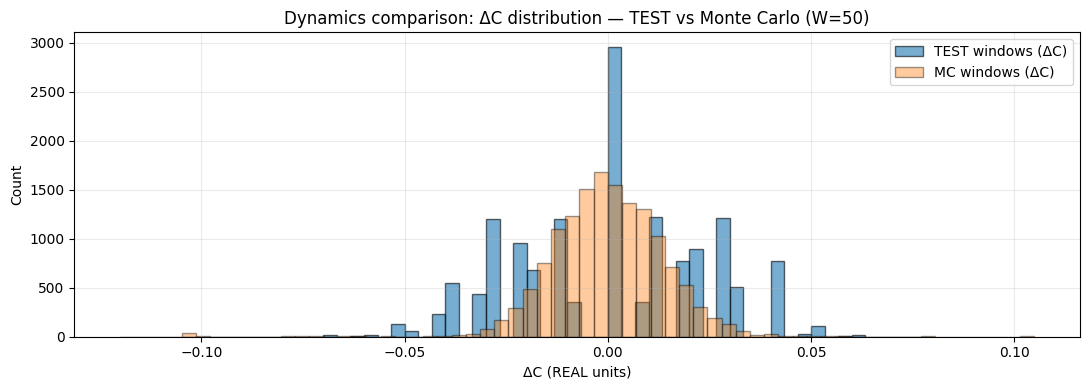

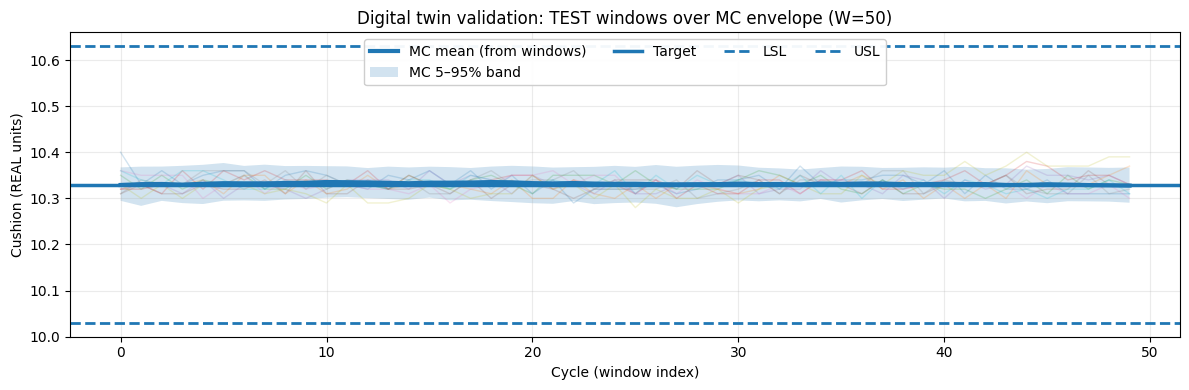


================ DOWNLOAD FIGURES ================


Button(button_style='success', description='Download Values Distribution PNG', icon='download', layout=Layout(…

Button(button_style='success', description='Download Dynamics Distribution PNG', icon='download', layout=Layou…

Button(button_style='success', description='Download Envelope Validation PNG', icon='download', layout=Layout(…

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
# ============================================================
# Digital Twin Validation Cell (50-cycle windows)
# Multi-view compatibility check: distribution + dynamics + envelope coverage
# - With manual download buttons for high-quality PNG
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from google.colab import files

# Optional scipy tests (KS). If scipy not available, we fallback to empirical metrics.
try:
    from scipy.stats import ks_2samp
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

req = ["runs", "df_test_raw", "TARGET_COL", "LSL", "USL", "TARGET_CUSHION"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

# ============================================================
# Export folder
# ============================================================
output_dir = "digital_twin_validation_outputs"
os.makedirs(output_dir, exist_ok=True)

# ============================================================
# Helper for download button
# ============================================================
def make_download_button(file_path, button_label):
    button = widgets.Button(
        description=button_label,
        button_style="success",
        icon="download",
        layout=widgets.Layout(width="320px")
    )

    def on_click(b):
        files.download(file_path)

    button.on_click(on_click)
    return button

# ----------------------------
# Settings
# ----------------------------
W = 50
N_WINDOWS = 300
RANDOM_SEED = 7
rng = np.random.default_rng(RANDOM_SEED)

runs_arr = np.asarray(runs, dtype=float)
n_runs, mc_len = runs_arr.shape
if mc_len < W:
    raise RuntimeError(f"MC has {mc_len} cycles after burn-in. Need W={W}. "
                       f"Set SIM_CYCLES = BURN_IN + {W} (e.g., 80 if burn-in=30).")

test_series = df_test_raw[TARGET_COL].astype(float).dropna().values
T = len(test_series)
if T < W:
    raise RuntimeError(f"TEST length {T} < W={W}.")

# ----------------------------
# Helper metrics
# ----------------------------
def cohen_d(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    na, nb = len(a), len(b)
    sa, sb = np.var(a, ddof=1), np.var(b, ddof=1)
    sp = np.sqrt(((na - 1) * sa + (nb - 1) * sb) / (na + nb - 2 + 1e-12))
    return float((np.mean(a) - np.mean(b)) / (sp + 1e-12))

def summarize(arr):
    arr = np.asarray(arr, float)
    return (
        float(np.mean(arr)),
        float(np.std(arr, ddof=1)),
        float(np.percentile(arr, 5)),
        float(np.percentile(arr, 95))
    )

# ----------------------------
# 1) Build comparable datasets: MANY 50-cycle windows
# ----------------------------

# A) MC windows: take random runs and use their first W cycles
mc_idx = rng.integers(0, n_runs, size=N_WINDOWS)
mc_windows = runs_arr[mc_idx, :W]
mc_vals = mc_windows.reshape(-1)
mc_deltas = np.diff(mc_windows, axis=1).reshape(-1)

# B) TEST windows: random contiguous windows
max_start = T - W
starts = rng.integers(0, max_start + 1, size=N_WINDOWS)
test_windows = np.stack([test_series[s:s+W] for s in starts], axis=0)
test_vals = test_windows.reshape(-1)
test_deltas = np.diff(test_windows, axis=1).reshape(-1)

# ----------------------------
# 2) Compare distributions (values + deltas)
# ----------------------------
mc_mu, mc_sig, mc_p5, mc_p95 = summarize(mc_vals)
ts_mu, ts_sig, ts_p5, ts_p95 = summarize(test_vals)

d_mu = cohen_d(mc_vals, test_vals)

mc_dmu, mc_dsig, mc_dp5, mc_dp95 = summarize(mc_deltas)
ts_dmu, ts_dsig, ts_dp5, ts_dp95 = summarize(test_deltas)

d_deltas = cohen_d(mc_deltas, test_deltas)

# KS tests (if available)
if HAS_SCIPY:
    ks_vals = ks_2samp(mc_vals, test_vals)
    ks_dlt  = ks_2samp(mc_deltas, test_deltas)
    ks_vals_stat, ks_vals_p = float(ks_vals.statistic), float(ks_vals.pvalue)
    ks_dlt_stat, ks_dlt_p   = float(ks_dlt.statistic), float(ks_dlt.pvalue)
else:
    ks_vals_stat = ks_vals_p = np.nan
    ks_dlt_stat  = ks_dlt_p  = np.nan

# ----------------------------
# 3) Envelope coverage test
# ----------------------------
mc_q05 = np.percentile(mc_windows, 5, axis=0)
mc_q95 = np.percentile(mc_windows, 95, axis=0)
mc_mean_path = np.mean(mc_windows, axis=0)

inside = (test_windows >= mc_q05[None, :]) & (test_windows <= mc_q95[None, :])
coverage = float(np.mean(inside))
full_covered = float(np.mean(np.all(inside, axis=1)))

# ----------------------------
# 4) Print interpretation
# ----------------------------
print("\n================ DIGITAL TWIN COMPATIBILITY (W=50) ================")
print("Cushion values (C):")
print(f"  MC:   mu={mc_mu:.4f}, sigma={mc_sig:.4f}, P5={mc_p5:.4f}, P95={mc_p95:.4f}")
print(f"  TEST: mu={ts_mu:.4f}, sigma={ts_sig:.4f}, P5={ts_p5:.4f}, P95={ts_p95:.4f}")
print(f"  Effect size (Cohen's d) on C values: {d_mu:.3f}  (|d|<0.2 small, <0.5 medium)")

if HAS_SCIPY:
    print(f"  KS test on C values: D={ks_vals_stat:.3f}, p={ks_vals_p:.4f}")

print("\nDynamics (ΔC):")
print(f"  MC:   mu={mc_dmu:.5f}, sigma={mc_dsig:.5f}, P5={mc_dp5:.5f}, P95={mc_dp95:.5f}")
print(f"  TEST: mu={ts_dmu:.5f}, sigma={ts_dsig:.5f}, P5={ts_dp5:.5f}, P95={ts_dp95:.5f}")
print(f"  Effect size (Cohen's d) on ΔC: {d_deltas:.3f}")

if HAS_SCIPY:
    print(f"  KS test on ΔC: D={ks_dlt_stat:.3f}, p={ks_dlt_p:.4f}")

print("\nEnvelope coverage (MC 5–95% band vs TEST windows):")
print(f"  Point-wise coverage: {coverage*100:.2f}%  (target ~90% if well calibrated)")
print(f"  Window fully-covered: {full_covered*100:.2f}% (strict criterion)")

print("\nPractical interpretation:")
print("  - If mean/std and ΔC std are close, and coverage ≈ 90%, the simulation is consistent with TEST regime.")
print("  - Large gaps in ΔC sigma or low coverage indicate mismatch in dynamics/noise assumptions.")
print("===================================================================\n")

# ----------------------------
# 5A) Overlaid distributions (values)
# ----------------------------
fig1, ax1 = plt.subplots(figsize=(11, 4))
ax1.hist(test_vals, bins=60, alpha=0.6, edgecolor="black", label="TEST windows (C)")
ax1.hist(mc_vals,   bins=60, alpha=0.4, edgecolor="black", label="MC windows (C)")
ax1.axvline(TARGET_CUSHION, linewidth=2.5, label="Target")
ax1.set_title("Distribution comparison: Cushion values (C) — TEST vs Monte Carlo (W=50)")
ax1.set_xlabel("Cushion (REAL units)")
ax1.set_ylabel("Count")
ax1.grid(True, alpha=0.25)
ax1.legend()
plt.tight_layout()
plt.show()

fig1_path = os.path.join(output_dir, "dt_validation_distribution_values.png")
fig1.savefig(fig1_path, dpi=600, bbox_inches="tight")
plt.close(fig1)

# ----------------------------
# 5B) Overlaid distributions (deltas)
# ----------------------------
fig2, ax2 = plt.subplots(figsize=(11, 4))
ax2.hist(test_deltas, bins=60, alpha=0.6, edgecolor="black", label="TEST windows (ΔC)")
ax2.hist(mc_deltas,   bins=60, alpha=0.4, edgecolor="black", label="MC windows (ΔC)")
ax2.set_title("Dynamics comparison: ΔC distribution — TEST vs Monte Carlo (W=50)")
ax2.set_xlabel("ΔC (REAL units)")
ax2.set_ylabel("Count")
ax2.grid(True, alpha=0.25)
ax2.legend()
plt.tight_layout()
plt.show()

fig2_path = os.path.join(output_dir, "dt_validation_distribution_deltas.png")
fig2.savefig(fig2_path, dpi=600, bbox_inches="tight")
plt.close(fig2)

# ----------------------------
# 5C) Envelope plot (digital twin band)
# ----------------------------
fig3, ax3 = plt.subplots(figsize=(12, 4))
x = np.arange(W)

for i in range(min(10, N_WINDOWS)):
    ax3.plot(test_windows[i], alpha=0.20, linewidth=1)

ax3.plot(mc_mean_path, linewidth=3, label="MC mean (from windows)")
ax3.fill_between(x, mc_q05, mc_q95, alpha=0.20, label="MC 5–95% band")
ax3.axhline(TARGET_CUSHION, linewidth=2.5, label="Target")
ax3.axhline(LSL, linestyle="--", linewidth=2.0, label="LSL")
ax3.axhline(USL, linestyle="--", linewidth=2.0, label="USL")

ax3.set_title(f"Digital twin validation: TEST windows over MC envelope (W={W})")
ax3.set_xlabel("Cycle (window index)")
ax3.set_ylabel("Cushion (REAL units)")
ax3.grid(True, alpha=0.25)
ax3.legend(loc="upper center", ncol=4, framealpha=0.95)
plt.tight_layout()
plt.show()

fig3_path = os.path.join(output_dir, "dt_validation_envelope.png")
fig3.savefig(fig3_path, dpi=600, bbox_inches="tight")
plt.close(fig3)

# ============================================================
# Download buttons
# ============================================================
print("\n================ DOWNLOAD FIGURES ================")
display(make_download_button(fig1_path, "Download Values Distribution PNG"))
display(make_download_button(fig2_path, "Download Dynamics Distribution PNG"))
display(make_download_button(fig3_path, "Download Envelope Validation PNG"))

# Phase 4 - Publishable Results Summary

This section generates article-ready summary tables from the full notebook workflow:

1. Model performance comparison
2. Uncertainty quality comparison
3. Capability comparison vs real process (Cp/Cpk, mean, sigma, out-of-spec)
4. Final recommendation text block

Optional: the tables are also exported as CSV files for direct use in a manuscript.


In [28]:
# ============================================================
# PUB CELL 1 - Table A: predictive performance and uncertainty
# ============================================================

import numpy as np
import pandas as pd

req = ["exp_results", "uncertainty_results", "score_df"]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(
        f"Missing objects {missing}. Run Phase 2 cells (Model Selection Experiment) before this section."
    )

rows = []
for model_name in score_df["model"].tolist():
    er = exp_results[model_name]
    ur = uncertainty_results[model_name]

    rows.append({
        "Model": model_name,
        "Rollout_RMSE": float(er["rollout_rmse"]),
        "Recipe_Sensitivity_Score": float(er["sensitivity_score"]),
        "Conformal_Coverage": float(ur["conformal"]["coverage"]),
        "Conformal_AvgWidth": float(ur["conformal"]["avg_width"]),
        "MCRes_Coverage": float(ur["monte_carlo_resid"]["coverage"]),
        "MCRes_AvgWidth": float(ur["monte_carlo_resid"]["avg_width"]),
        "Selected_Uncertainty": str(score_df.loc[score_df["model"] == model_name, "best_uncertainty"].iloc[0]),
        "Final_Score": float(score_df.loc[score_df["model"] == model_name, "final_score"].iloc[0]),
    })

table_model_perf = pd.DataFrame(rows).sort_values("Final_Score", ascending=False).reset_index(drop=True)

print("Table A - Predictive performance and uncertainty quality")
display(table_model_perf)


Table A - Predictive performance and uncertainty quality


,Model,Rollout_RMSE,Recipe_Sensitivity_Score,Conformal_Coverage,Conformal_AvgWidth,MCRes_Coverage,MCRes_AvgWidth,Selected_Uncertainty,Final_Score
0,TCN,0.013810,0.081840,0.911187,0.047565,0.910401,0.047585,monte_carlo_resid,0.995657
1,LSTM,0.014480,0.070049,0.904637,0.047314,0.906733,0.046941,conformal,0.558867
2,GRU,0.014867,0.052533,0.910925,0.046989,0.904113,0.046403,monte_carlo_resid,0.196699


In [29]:
# ============================================================
# PUB CELL 2 - Table B: capability comparison vs REAL process
# ============================================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# Define TimeSeriesDataset if not already in scope (e.g., from an earlier cell)
class TimeSeriesDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)  # (N, SEQ_LEN, n_features)
        self.Y = torch.tensor(Y, dtype=torch.float32)  # (N, H)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# Create test_loader if not already in scope
if 'test_loader' not in globals():
    test_loader = DataLoader(
        TimeSeriesDataset(X_test, Y_test),
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False
    )

req = [
    "compute_cp_cpk", "df_test_raw", "TARGET_COL", "LSL", "USL", "FEATURES", "SEQ_LEN",
    "x_scaler", "delta_scaler", "test_loader", "device", "feature_sigma",
    "N_SIMS", "SIM_CYCLES", "BURN_IN", "NOISE_SCALE", "USE_FEATURE_NOISE", "USE_RESIDUAL_NOISE",
    "USE_EMPIRICAL_RESID", "USE_AR1_RESIDUAL", "AR1_RHO", "USE_DELTA_CLAMP", "USE_CUSHION_CLAMP",
    "CUSH_MIN", "CUSH_MAX", "INIT_MODE", "df_train_raw", "RECIPE_REAL", "experiment_models"
]
missing = [r for r in req if r not in globals()]
if missing:
    raise RuntimeError(
        f"Missing objects {missing}. Run Phase 2-4 evaluation cells before this section."
    )

candidate_models = {name: info["model"] for name, info in experiment_models.items()}
if len(candidate_models) == 0:
    raise RuntimeError("No trained models found in experiment_models.")

cush_in_idx = FEATURES.index("Cushion_in")


def _pred_delta_scaled(model_in, xb):
    out = model_in(xb)
    if out.ndim == 2:
        out = out[:, 0]
    elif out.ndim > 2:
        out = out.reshape(out.shape[0], -1)[:, 0]
    return out


def _calibrate_residuals(model_in, loader):
    model_in.eval()
    p_all, t_all = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model_in(xb)

            # ensure shape (B,1)
            if preds.ndim == 1:
                preds = preds.unsqueeze(1)
            if yb.ndim == 1:
                yb = yb.unsqueeze(1)

            # one-step only
            p1 = preds[:, 0].detach().cpu().numpy().reshape(-1, 1)
            t1 = yb[:, 0].detach().cpu().numpy().reshape(-1, 1)

            p_all.append(p1)
            t_all.append(t1)

    p_s = np.vstack(p_all)
    t_s = np.vstack(t_all)
    p_r = delta_scaler.inverse_transform(p_s).ravel().astype(np.float32)
    t_r = delta_scaler.inverse_transform(t_s).ravel().astype(np.float32)
    resid = (t_r - p_r).astype(np.float32)
    sigma = float(np.std(resid, ddof=1))
    bias = float(np.mean(resid))
    clamp = float(np.quantile(np.abs(resid), 0.995)) if len(resid) > 0 else 0.0
    return resid, sigma, bias, clamp


if "scale_x_fast" not in globals() or "delta_scaled_to_real_fast" not in globals():
    _x_mean = getattr(x_scaler, "mean_", None)
    _x_scale = getattr(x_scaler, "scale_", None)

    def scale_x_fast(x_real: np.ndarray) -> np.ndarray:
        if _x_mean is not None and _x_scale is not None:
            return ((x_real - _x_mean) / _x_scale).astype(np.float32)
        import pandas as pd
        shp = x_real.shape
        x2 = x_real.reshape(-1, shp[-1])
        x2s = x_scaler.transform(pd.DataFrame(x2, columns=FEATURES)).astype(np.float32)
        return x2s.reshape(*shp)

    _d_mean = float(getattr(delta_scaler, "mean_", [0.0])[0])
    _d_scale = float(getattr(delta_scaler, "scale_", [1.0])[0])

    def delta_scaled_to_real_fast(d_scaled: np.ndarray) -> np.ndarray:
        return d_scaled * _d_scale + _d_mean


def _run_mc(model_in, sigma_res, bias_res, residual_pool, clamp_abs):
    n_runs = int(N_SIMS)
    steps = int(SIM_CYCLES)
    n_feat = len(FEATURES)

    if INIT_MODE == "test_mean":
        c0 = float(df_test_raw[TARGET_COL].astype(float).mean())
    elif INIT_MODE == "train_mean":
        c0 = float(df_train_raw[TARGET_COL].astype(float).mean())
    elif INIT_MODE == "last_train":
        c0 = float(df_train_raw[TARGET_COL].astype(float).iloc[-1])
    elif INIT_MODE == "custom":
        c0 = float(INIT_CUSHION_REAL)
    else:
        raise ValueError("INIT_MODE invalid")

    base_row = np.zeros((n_feat,), dtype=np.float32)
    for i, f in enumerate(FEATURES):
        if f == "Cushion_in":
            base_row[i] = c0
        elif f in RECIPE_REAL:
            base_row[i] = float(RECIPE_REAL[f])
        elif f in df_train_raw.columns:
            base_row[i] = float(df_train_raw[f].astype(float).mean())
        else:
            base_row[i] = 0.0

    sigma_vec = np.array([float(feature_sigma.get(f, 0.0)) for f in FEATURES], dtype=np.float32)
    sigma_vec[cush_in_idx] = 0.0
    sigma_vec *= float(NOISE_SCALE)

    seq_real = np.tile(base_row, (n_runs, SEQ_LEN, 1)).astype(np.float32)
    seq_real[:, :, cush_in_idx] = c0
    if USE_FEATURE_NOISE and np.any(sigma_vec > 0):
        seq_real += np.random.normal(0.0, sigma_vec, size=seq_real.shape).astype(np.float32)

    seq_scaled = scale_x_fast(seq_real)
    seq_t = torch.from_numpy(seq_scaled).to(device=device, dtype=torch.float32)

    c_prev = torch.full((n_runs,), float(c0), device=device, dtype=torch.float32)
    traj = np.empty((n_runs, steps), dtype=np.float32)
    base_row_batch = np.tile(base_row, (n_runs, 1)).astype(np.float32)
    e_prev = np.zeros((n_runs,), dtype=np.float32)

    model_in.eval()
    with torch.no_grad():
        for k in range(steps):
            d_s = _pred_delta_scaled(model_in, seq_t).detach().cpu().numpy().astype(np.float32)
            d_r = delta_scaled_to_real_fast(d_s)
            d_r += float(bias_res)

            if USE_RESIDUAL_NOISE and sigma_res > 0:
                if USE_EMPIRICAL_RESID and residual_pool is not None and len(residual_pool) > 100:
                    e = np.random.choice(residual_pool, size=n_runs, replace=True).astype(np.float32)
                else:
                    e = np.random.normal(0.0, float(sigma_res), size=(n_runs,)).astype(np.float32)
                e *= float(NOISE_SCALE)

                if USE_AR1_RESIDUAL:
                    rho = float(AR1_RHO)
                    e = rho * e_prev + np.sqrt(max(1e-8, 1.0 - rho * rho)) * e
                    e_prev = e

                d_r += e

            if USE_DELTA_CLAMP:
                cabs = float(clamp_abs) * float(NOISE_SCALE)
                d_r = np.clip(d_r, -cabs, cabs)

            d_t = torch.from_numpy(d_r).to(device=device, dtype=torch.float32)
            c_next = c_prev + d_t
            if USE_CUSHION_CLAMP:
                c_next = torch.clamp(c_next, float(CUSH_MIN), float(CUSH_MAX))

            traj[:, k] = c_next.detach().cpu().numpy()

            next_row = base_row_batch.copy()
            if USE_FEATURE_NOISE and np.any(sigma_vec > 0):
                next_row += np.random.normal(0.0, sigma_vec, size=(n_runs, n_feat)).astype(np.float32)
            next_row[:, cush_in_idx] = traj[:, k]

            next_scaled = scale_x_fast(next_row)
            next_t = torch.from_numpy(next_scaled).to(device=device, dtype=torch.float32)
            seq_t[:, :-1, :] = seq_t[:, 1:, :]
            seq_t[:, -1, :] = next_t
            c_prev = c_next

    return traj[:, BURN_IN:] if BURN_IN > 0 else traj


real_samples = df_test_raw[TARGET_COL].astype(float).dropna().values
real_stats = compute_cp_cpk(real_samples, LSL, USL)

rows = [{
    "Source": "REAL_TEST",
    "Mean": float(real_stats["mu"]),
    "Sigma": float(real_stats["sigma"]),
    "Cp": float(real_stats["Cp"]),
    "Cpk": float(real_stats["Cpk"]),
    "Out_of_Spec_%": float(real_stats["P_out"] * 100.0),
}]

for name, mdl in candidate_models.items():
    resid, sigma, bias, clamp = _calibrate_residuals(mdl, test_loader)
    runs_local = _run_mc(mdl, sigma, bias, resid, clamp)
    st = compute_cp_cpk(runs_local.reshape(-1), LSL, USL)
    rows.append({
        "Source": f"MC_{name}",
        "Mean": float(st["mu"]),
        "Sigma": float(st["sigma"]),
        "Cp": float(st["Cp"]),
        "Cpk": float(st["Cpk"]),
        "Out_of_Spec_%": float(st["P_out"] * 100.0),
    })

table_capability = pd.DataFrame(rows)
print("Table B - Capability comparison vs real process")
display(table_capability)


Table B - Capability comparison vs real process


,Source,Mean,Sigma,Cp,Cpk,Out_of_Spec_%
0,REAL_TEST,10.335669,0.023551,4.246037,4.165808,0.0
1,MC_TCN,10.341239,0.020455,4.888733,4.705580,0.0
2,MC_GRU,10.303500,0.020220,4.945574,4.508722,0.0
3,MC_LSTM,10.300447,0.021835,4.579829,4.128670,0.0


In [30]:
# ============================================================
# PUB CELL 3 - Figure-ready compact summary + CSV export
# ============================================================

import pandas as pd

best_row = table_model_perf.iloc[0]
best_model = str(best_row["Model"])

summary_rows = []
summary_rows.append({"Item": "Best model", "Value": best_model})
summary_rows.append({"Item": "Best final score", "Value": f"{float(best_row['Final_Score']):.4f}"})
summary_rows.append({"Item": "Best rollout RMSE", "Value": f"{float(best_row['Rollout_RMSE']):.5f}"})
summary_rows.append({"Item": "Best uncertainty method", "Value": str(best_row["Selected_Uncertainty"])})

cap_key = f"MC_{best_model}"
cap_row = table_capability.loc[table_capability["Source"] == cap_key]
if len(cap_row) == 1:
    r = cap_row.iloc[0]
    summary_rows.append({"Item": "Best-model MC Cp", "Value": f"{float(r['Cp']):.3f}"})
    summary_rows.append({"Item": "Best-model MC Cpk", "Value": f"{float(r['Cpk']):.3f}"})
    summary_rows.append({"Item": "Best-model MC Out-of-Spec %", "Value": f"{float(r['Out_of_Spec_%']):.2f}"})

summary_table = pd.DataFrame(summary_rows)
print("Table C - Executive summary (article-ready)")
display(summary_table)

out_a = "publishable_table_A_model_performance.csv"
out_b = "publishable_table_B_capability_vs_real.csv"
out_c = "publishable_table_C_executive_summary.csv"
table_model_perf.to_csv(out_a, index=False)
table_capability.to_csv(out_b, index=False)
summary_table.to_csv(out_c, index=False)

print("\nCSV files exported:")
print("-", out_a)
print("-", out_b)
print("-", out_c)

print("\nSuggested manuscript wording (draft):")
print(
    f"The {best_model}-based soft sensor achieved the best overall trade-off between rollout error and calibrated uncertainty. "
    "Capability analysis using Monte Carlo simulation showed close agreement to the real TEST process distribution, "
    "supporting its use as a virtual SPC and recipe evaluation tool."
)


Table C - Executive summary (article-ready)


,Item,Value
0,Best model,TCN
1,Best final score,0.9957
2,Best rollout RMSE,0.01381
3,Best uncertainty method,monte_carlo_resid
4,Best-model MC Cp,4.889
5,Best-model MC Cpk,4.706
6,Best-model MC Out-of-Spec %,0.00



CSV files exported:
- publishable_table_A_model_performance.csv
- publishable_table_B_capability_vs_real.csv
- publishable_table_C_executive_summary.csv

Suggested manuscript wording (draft):
The TCN-based soft sensor achieved the best overall trade-off between rollout error and calibrated uncertainty. Capability analysis using Monte Carlo simulation showed close agreement to the real TEST process distribution, supporting its use as a virtual SPC and recipe evaluation tool.
